# <h1 style="text-align: center;">4. PREDICTIVE — Machine Learning Models</h1>

## Setup: data, features and evaluation method
**Data:** `Team05_PyCraft_Cleaned_data/wide_merged_table.csv` (2,008 patients × 193 columns).

**Feature groups** (only information known **at admission**, so no model "cheats" with data recorded after the outcome):

| Group | Columns |
|---|---|
| Demography | age (midpoint of `age_category`), sex, BMI, weight, height |
| Comorbidities | 17 disease flags + `cci_score` |
| Cardiac function | `heart_failure_severity` (NYHA class), `heart_damage_level` (Killip class), `severe_hf`, `heart_failure_type`, LVEF (`heart_pumping_efficiency`), other echo measures |
| Vitals | temperature, pulse, respiration, SBP, DBP, MAP, FiO2, oxygen therapy |
| Consciousness | `gcs`, `eye_opening`, `verbal_response`, `movement`, `consciousness` |
| Labs | 88 lab tests recorded for at least 40% of patients |
| Admission | emergency admission, admission ward |

Outcome columns (`death_*`, `readmission_*`, `hospitalization_outcome`, `discharge_day`, `discharge_destination`, `discharge_department`), follow-up times and `visit_count` are **never** used as features.

**Models:** Logistic Regression (median imputation + scaling, class-balanced) and Random Forest (300 trees, class-balanced).

**How accuracy is measured:** repeated **stratified 5-fold cross-validation** — every patient is predicted by a model that never saw them.
- **ROC-AUC** (main metric): how well the model ranks patients who have the event above those who don't. 0.5 = chance, 0.7 = acceptable, 0.8 = good, 0.9 = excellent.
- **PR-AUC**: precision across all thresholds — the honest metric when events are rare (chance level = the event rate).
- **Accuracy, Precision, Recall, F1**: for a practical rule that **flags the top 10% highest-risk patients**.

> Deaths are rare (2.8% at 6 months), so plain **accuracy is misleading** — a model that predicts "nobody dies" is 97% accurate but useless. Questions were therefore selected on **ROC-AUC ≥ 0.74** with precision well above the event rate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
                             mean_absolute_error, r2_score)

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv", low_memory=False)

# ---------------- Derived features (all known at admission) ----------------
age_mid_map = {'21-29': 25, '29-39': 34, '39-49': 44, '49-59': 54, '59-69': 64, '69-79': 74, '79-89': 84, '89-110': 95}
df['age_mid'] = df['age_category'].map(age_mid_map)
df['male'] = (df['gender'] == 'Male').astype(int)
df['emergency'] = (df['admission_type'] == 'Emergency').astype(int)
df['on_oxygen'] = (df['oxygen_therapy'] == 'OxygenTherapy').astype(int)
df['conscious_clear'] = (df['consciousness'] == 'Clear').astype(int)
for t in ['Left', 'Right', 'Both']:
    df['hf_' + t.lower()] = (df['heart_failure_type'] == t).astype(int)
for w in ['Cardiology', 'GeneralWard', 'ICU', 'Others']:
    df['adm_' + w] = (df['admission_ward'] == w).astype(int)

# ---------------- Feature groups ----------------
DEMO = ['age_mid', 'male', 'bmi', 'weight', 'height']
COMOR = ['cerebrovascular_disease', 'dementia', 'chronic_obstructive_pulmonary_disease', 'connective_tissue_disease',
         'peptic_ulcer_disease', 'diabetes', 'moderate_to_severe_chronic_kidney_disease', 'hemiplegia',
         'malignant_lymphoma', 'solid_tumor', 'liver_disease', 'aids', 'cci_score', 'type2_respiratory_failure',
         'acute_renal_failure', 'heart_attack_history', 'congestive_heart_failure', 'peripheral_vascular_disease']
CARD = ['heart_failure_severity', 'heart_damage_level', 'severe_hf', 'hf_left', 'hf_right', 'hf_both',
        'heart_pumping_efficiency', 'left_ventricle_size', 'mitral_valve_ems', 'pulmonary_velocity']
VITALS = ['temp', 'pulse', 'resp', 'sbp', 'dbp', 'MAP', 'FiO2', 'on_oxygen']
GCS = ['gcs', 'eye_opening', 'verbal_response', 'movement', 'conscious_clear']
ADMIT = ['emergency', 'adm_Cardiology', 'adm_GeneralWard', 'adm_ICU', 'adm_Others']
cols = list(df.columns)
LABS = [c for c in cols[cols.index('creatinine'):cols.index('total_hemoglobin') + 1]
        if df[c].isna().mean() < 0.6 and df[c].nunique() > 1]          # labs recorded for at least 40% of patients
DRUGS = [c for c in cols if c.startswith('drug_')] + ['num_distinct_drugs']
SEVERITY = ['heart_failure_severity', 'heart_damage_level', 'severe_hf']   # NYHA class, Killip class, severe-HF flag
print("Patients:", len(df), "| Lab features used:", len(LABS))

# ---------------- Models ----------------
def logreg():
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                         LogisticRegression(max_iter=3000, C=0.1, class_weight='balanced'))

def rforest():
    return make_pipeline(SimpleImputer(strategy='median'),
                         RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                class_weight='balanced_subsample', random_state=42, n_jobs=-1))

# ---------------- Evaluation: repeated stratified 5-fold cross-validation ----------------
def evaluate(name, model, X, y, reps=3, top_frac=0.10):
    """ROC-AUC / PR-AUC averaged over `reps` repeats of 5-fold CV.
    Accuracy, precision, recall and F1 are for flagging the top `top_frac` highest-risk patients."""
    aucs, aps, preds = [], [], []
    for r in range(reps):
        p = cross_val_predict(model, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=r),
                              method='predict_proba')[:, 1]
        aucs.append(roc_auc_score(y, p)); aps.append(average_precision_score(y, p)); preds.append(p)
    p = np.mean(preds, axis=0)
    flag = (p >= np.quantile(p, 1 - top_frac)).astype(int)
    res = {'Model': name, 'Patients': len(y), 'Events': int(y.sum()), 'Event rate %': round(y.mean() * 100, 1),
           'ROC-AUC': round(np.mean(aucs), 3), 'ROC-AUC SD': round(np.std(aucs), 3), 'PR-AUC': round(np.mean(aps), 3),
           'Accuracy': round(accuracy_score(y, flag), 3), 'Precision': round(precision_score(y, flag, zero_division=0), 3),
           'Recall': round(recall_score(y, flag), 3), 'F1': round(f1_score(y, flag), 3)}
    return res, p

def plot_roc(curves, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    for label, (y, p) in curves.items():
        fpr, tpr, _ = roc_curve(y, p)
        ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC {roc_auc_score(y, p):.3f})")
    ax.plot([0, 1], [0, 1], '--', color='grey', label='Chance (AUC 0.5)')
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate (recall)')
    ax.set_title(title); ax.legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()

def plot_confusion(y, p, title, top_frac=0.10):
    flag = (p >= np.quantile(p, 1 - top_frac)).astype(int)
    cm = confusion_matrix(y, flag)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Predicted low risk', 'Flagged high risk'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual: no event', 'Actual: event'])
    ax.set_title(title, fontsize=10); plt.tight_layout(); plt.show()


Patients: 2008 | Lab features used: 88


## Detailed evaluation helpers
For **every question**, each model is reported with the full set of classification metrics:
- **Accuracy** — share of all patients classified correctly
- **Precision** — of the patients the model flags, the share who really had the event
- **Recall (sensitivity)** — of all patients who had the event, the share the model flagged
- **F1-score** — the balance (harmonic mean) of precision and recall
- **ROC-AUC** — how well the model ranks patients with the event above those without (0.5 = chance, 1.0 = perfect)
- **Confusion matrix** — counts of true negatives (TN), false positives (FP), false negatives (FN) and true positives (TP)
- **Classification report** — precision, recall, F1 and support (number of patients) for **each class** separately, plus macro and weighted averages

**Decision rule:** a risk model outputs a probability, so a cut-off is needed to turn it into "flag / don't flag". Each question uses a practical rule: flag the **top 10%** highest-risk patients for rare outcomes (death), and a share close to the event rate for common outcomes (top 20% for HFrEF, 30% for inotropes, 50% for digitalis). All predictions are **cross-validated** (each patient scored by a model that never saw them). The ROC-AUC printed in these reports is computed on the averaged cross-validated probabilities, so it can differ from the table values (mean of per-repeat AUCs) by about ±0.01.

In [2]:
from sklearn.metrics import classification_report

ALL_METRICS = []   # collects one row per model for the final summary table

def full_report(question, name, y, p, top_frac=0.10, thr=None):
    """Print accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report.
    Patients with predicted probability >= threshold are flagged (default: top `top_frac` of risk)."""
    y = np.asarray(y); p = np.asarray(p)
    if thr is None:
        thr = np.quantile(p, 1 - top_frac)
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    m = {'Question': question, 'Model': name, 'Patients': len(y), 'Events': int(y.sum()),
         'Flagged': int(pred.sum()), 'Accuracy': accuracy_score(y, pred),
         'Precision': precision_score(y, pred, zero_division=0), 'Recall': recall_score(y, pred),
         'F1': f1_score(y, pred, zero_division=0), 'ROC-AUC': roc_auc_score(y, p),
         'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}
    ALL_METRICS.append(m)
    print("=" * 78)
    print(f"{question} | {name}")
    print(f"Decision rule: flag patients with predicted probability >= {thr:.3f} ({pred.mean():.1%} of patients flagged)")
    print(f"Accuracy {m['Accuracy']:.3f} | Precision {m['Precision']:.3f} | Recall {m['Recall']:.3f} | "
          f"F1 {m['F1']:.3f} | ROC-AUC {m['ROC-AUC']:.3f}")
    print(f"Confusion matrix: TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")
    print("Classification report:")
    print(classification_report(y, pred, labels=[0, 1], target_names=['No event (0)', 'Event (1)'], digits=3, zero_division=0))
    return pred

def cm_grid(items, title):
    """Plot several confusion matrices side by side. items = list of (subtitle, y, pred)."""
    n = len(items); ncol = min(n, 3); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 4 * nrow), squeeze=False)
    for ax, (sub, y, pred) in zip(axes.ravel(), items):
        cm = confusion_matrix(np.asarray(y), pred, labels=[0, 1])
        ax.imshow(cm, cmap='Blues')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{['TN', 'FP', 'FN', 'TP'][2 * i + j]}\n{cm[i, j]}", ha='center', va='center',
                        fontsize=11, fontweight='bold', color='white' if cm[i, j] > cm.max() / 2 else 'black')
        ax.set_xticks([0, 1]); ax.set_xticklabels(['Not flagged', 'Flagged'], fontsize=8)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual: no event', 'Actual: event'], fontsize=8)
        ax.set_title(sub, fontsize=9)
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    fig.suptitle(title, fontsize=11); plt.tight_layout(); plt.show()


### Screening result

| Candidate question | Result | Decision |
|---|---|---|
| ICU transfer among patients on respiratory support (blood gas + severity) | Only **42** patients on respiratory support and **4** ICU events | ❌ Not modelled — far too few events |
| Does older age or disease severity predict death/readmission? | Severity → death **AUC 0.745**; age ≈ chance | ✅ **Question 1** |
| Predict 6-month readmission (admission/discharge data) | AUC **0.666** | ❌ Weak |
| Predict 28-day readmission at discharge | AUC **0.664** | ❌ Weak |
| Predict 6-month mortality from admission-day data | AUC **0.777** | ✅ **Question 2** |
| Do labs add to demography + comorbidities for readmission? | AUC **0.634** | ❌ Weak |
| GCS beyond cardiac severity for mortality | AUC **0.843** (28-day death; only 11 in-hospital deaths) | ✅ **Question 3** |
| Predict discharge against medical advice | AUC **0.667** | ❌ Weak |
| Predict length of stay from first-24-hour data | R² **0.08**; MAE 4.1 days — worse than always guessing the median (4.0 days) | ❌ No useful prediction |
| Medication patterns + severity for readmission | AUC **0.666** | ❌ Weak |
| HF subtype added to LVEF + NYHA + Killip for mortality | AUC **0.746 → 0.759–0.778** | ✅ **Question 4** |
| Model performance in elderly (69+) vs younger patients | Mortality model AUC **0.816** (elderly) | ✅ **Question 5** |
| Which feature category contributes most to 6-month mortality? | Full model AUC **0.798** | ✅ **Question 6** |

**Key message:** mortality can be predicted well from admission data (AUC 0.75–0.85), but **readmission cannot** (AUC ≤ 0.67) — readmission depends on things this dataset does not record (post-discharge care, adherence, social support).

## 1. Does older age predict death or readmission in this elderly HF cohort, or does disease severity matter more?
### Reasoning
Almost three-quarters of the patients (73%) are 69 or older, and in practice age is often used as a quick shorthand for "high risk" — older patients get more cautious discharge plans and more follow-up. But age is only useful if it actually separates patients who die or are readmitted from those who do not. Heart-failure severity grades (NYHA and Killip class) are recorded for every patient at admission and describe how sick the heart is right now. If severity predicts outcomes and age does not, care intensity should follow severity. We build three models for each outcome — **age only**, **severity only** and **age + severity** — and compare how well each ranks patients.

### Hypothesis
- **H1:** Disease severity (NYHA, Killip, severe HF) predicts 6-month death better than age.
- **H2:** Adding age to severity does not improve the prediction, because in an already elderly cohort age varies little and adds no new information.
- **H3:** Neither age nor severity predicts 6-month readmission well, because readmission depends on factors after discharge.

### Features / Biomarkers used
- **Age:** `age_mid` — midpoint of `age_category` (e.g., 69–79 → 74)
- **Severity:** `heart_failure_severity` (NYHA class 2–4: symptom severity), `heart_damage_level` (Killip class 1–4: signs of heart failure/shock at admission), `severe_hf` (1 = severe breathlessness **and** severe congestion/shock)
- **Outcomes:** `death_6m` (57 deaths, 2.8%), `readmission_6m` (773 readmissions, 38.5%)

### Model used
**Logistic Regression** (median imputation → standardisation → logistic regression with L2 penalty C = 0.1 and class-balanced weights), 6 models in total (3 feature sets × 2 outcomes).

### Why this model was chosen
- **Simple and transparent:** each feature gets one coefficient, so we can see exactly how much it raises or lowers risk.
- **Works well with few features** (here 1–8), where a complex model has nothing extra to learn and would only add noise.
- **Features are standardised**, so the coefficients are directly comparable with each other.
- **L2 regularisation (C = 0.1)** shrinks unstable coefficients — important because there are few events.
- **Class-balanced weighting** makes the rare deaths count as much as the many survivors.
- The question is about **comparing the value of two simple predictors**, not about building the most complex model — a transparent model makes the comparison fair and easy to explain.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [3]:
targets = {'death_6m': '6-month death', 'readmission_6m': '6-month readmission'}
feature_sets = {'Age only': ['age_mid'], 'Severity only': SEVERITY, 'Age + Severity': ['age_mid'] + SEVERITY}
rows, curves = [], {}
for tgt, tname in targets.items():
    for fname, feats in feature_sets.items():
        res, p = evaluate(f"{tname} | {fname}", logreg(), df[feats], df[tgt])
        rows.append(res)
        if tgt == 'death_6m':
            curves[fname] = (df[tgt], p)
q1 = pd.DataFrame(rows).set_index('Model')
print(q1[['Events', 'Event rate %', 'ROC-AUC', 'ROC-AUC SD', 'PR-AUC', 'Accuracy', 'Precision', 'Recall', 'F1']].to_string())

# Crude rates for context
print("\n6-month death (%) by age group:"); print((df.groupby('age_category')['death_6m'].mean() * 100).round(1).to_dict())
print("6-month death (%) by NYHA class (heart_failure_severity):"); print((df.groupby('heart_failure_severity')['death_6m'].mean() * 100).round(1).to_dict())
print("6-month death (%) by Killip class (heart_damage_level):"); print((df.groupby('heart_damage_level')['death_6m'].mean() * 100).round(1).to_dict())
print("6-month death (%) by severe_hf:"); print((df.groupby('severe_hf')['death_6m'].mean() * 100).round(1).to_dict())


                                      Events  Event rate %  ROC-AUC  ROC-AUC SD  PR-AUC  Accuracy  Precision  Recall     F1
Model                                                                                                                      
6-month death | Age only                  57           2.8    0.466       0.044   0.027     0.875      0.025   0.088  0.038
6-month death | Severity only             57           2.8    0.745       0.005   0.131     0.890      0.095   0.333  0.147
6-month death | Age + Severity            57           2.8    0.737       0.006   0.132     0.891      0.100   0.351  0.155
6-month readmission | Age only           773          38.5    0.510       0.002   0.389     0.598      0.415   0.110  0.174
6-month readmission | Severity only      773          38.5    0.547       0.005   0.423     0.598      0.413   0.107  0.170
6-month readmission | Age + Severity     773          38.5    0.547       0.004   0.418     0.596      0.403   0.105  0.166

6-month

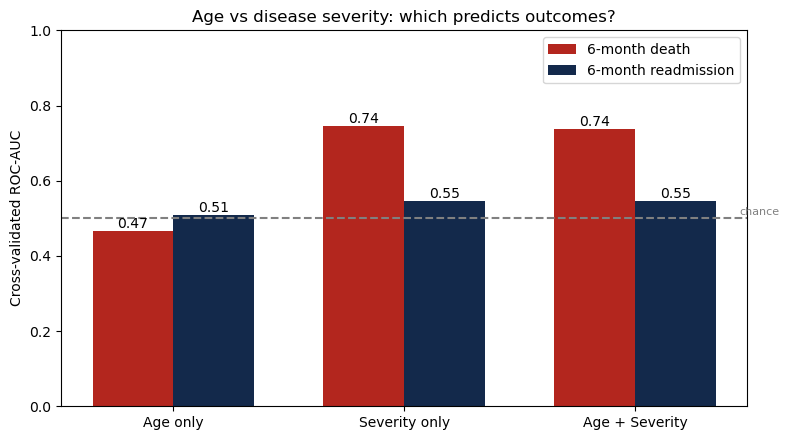

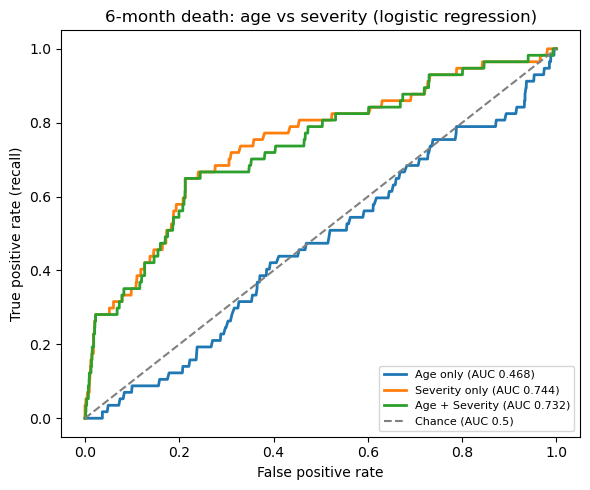

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = q1['ROC-AUC'].values.reshape(2, 3)
x = np.arange(3); w = 0.35
b1 = ax.bar(x - w/2, plot_df[0], w, label='6-month death', color='#B3261E')
b2 = ax.bar(x + w/2, plot_df[1], w, label='6-month readmission', color='#13294B')
ax.bar_label(b1, fmt='%.2f'); ax.bar_label(b2, fmt='%.2f')
ax.axhline(0.5, ls='--', color='grey'); ax.text(2.45, 0.51, 'chance', color='grey', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(list(feature_sets)); ax.set_ylim(0, 1); ax.set_ylabel('Cross-validated ROC-AUC')
ax.set_title('Age vs disease severity: which predicts outcomes?'); ax.legend(); plt.tight_layout(); plt.show()

plot_roc(curves, '6-month death: age vs severity (logistic regression)')


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
Every model in this question (3 feature sets × 2 outcomes) is evaluated with the top-10% flag rule. The death models use the cross-validated predictions from above; the readmission models are re-scored here.

Q1 | 6-month death | Age only
Decision rule: flag patients with predicted probability >= 0.520 (10.2% of patients flagged)
Accuracy 0.875 | Precision 0.025 | Recall 0.088 | F1 0.038 | ROC-AUC 0.468
Confusion matrix: TN = 1752, FP = 199, FN = 52, TP = 5
Classification report:
              precision    recall  f1-score   support

No event (0)      0.971     0.898     0.933      1951
   Event (1)      0.025     0.088     0.038        57

    accuracy                          0.875      2008
   macro avg      0.498     0.493     0.486      2008
weighted avg      0.944     0.875     0.908      2008

Q1 | 6-month death | Severity only
Decision rule: flag patients with predicted probability >= 0.700 (10.0% of patients flagged)
Accuracy 0.890 | Precision 0.095 | Recall 0.333 | F1 0.147 | ROC-AUC 0.744
Confusion matrix: TN = 1769, FP = 182, FN = 38, TP = 19
Classification report:
              precision    recall  f1-score   support

No event (0)      0.979     0.907     0.941      1951
   Eve

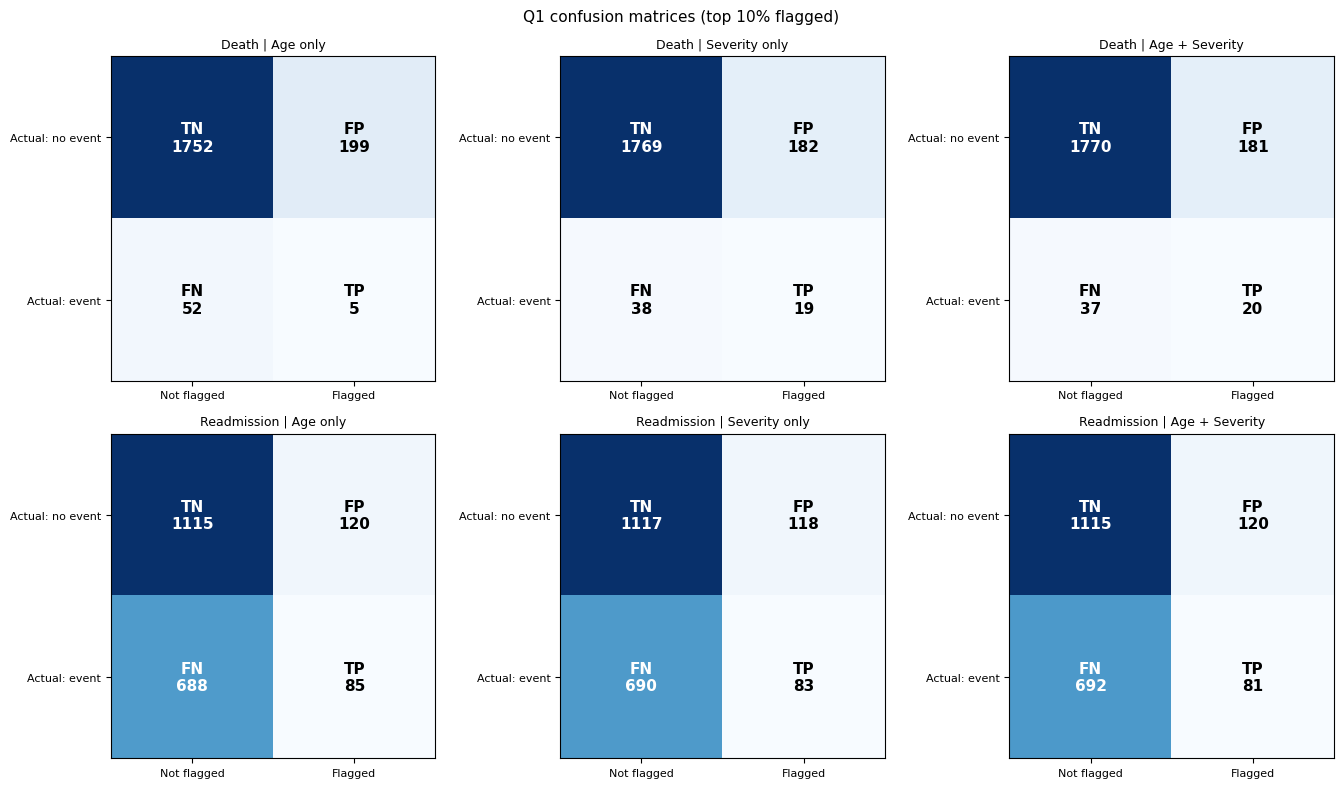

In [5]:
items = []
for fname in feature_sets:
    pred = full_report('Q1', f'6-month death | {fname}', df['death_6m'], curves[fname][1])
    items.append((f'Death | {fname}', df['death_6m'], pred))
for fname, feats in feature_sets.items():
    _, p_r = evaluate(fname, logreg(), df[feats], df['readmission_6m'])
    pred = full_report('Q1', f'6-month readmission | {fname}', df['readmission_6m'], p_r)
    items.append((f'Readmission | {fname}', df['readmission_6m'], pred))
cm_grid(items, 'Q1 confusion matrices (top 10% flagged)')


### How to read the chart
**Chart 1 — bar chart:** three pairs of bars, one pair per feature set (Age only, Severity only, Age + Severity). The **red bar** is the model's ROC-AUC for 6-month death, the **navy bar** for 6-month readmission. The **dashed grey line at 0.5** is chance level: a bar at or below it means the model is no better than guessing. The taller the bar above the line, the better the features separate patients who had the event from those who did not.

**Chart 2 — ROC curve (6-month death):** each line shows, for every possible risk cut-off, the share of deaths caught (y-axis, recall) against the share of survivors wrongly flagged (x-axis). A line bulging towards the **top-left corner** is a good model; a line along the **diagonal** is guessing. The AUC in the legend is the area under each line.

### Key Insights
- **Age does not predict death at all.** The age-only model scores **AUC 0.466** — slightly *below* chance. The death rate is essentially flat across age groups (1.8–3.8% from age 39 upward, and 3.0% in 89–110).
- **Disease severity clearly predicts death (AUC 0.745)** — H1 is confirmed. The strongest driver is the **Killip class**: 6-month death rises from **0.8% (Killip 1) → 1.6% (Killip 2) → 5.4% (Killip 3) → 26.7% (Killip 4)**. Patients flagged `severe_hf` die at **8.5% vs 1.5%** (≈ 6×).
- **Adding age to severity changes nothing** (0.737 vs 0.745, within noise) — H2 is confirmed.
- **Neither age nor severity predicts readmission** (AUC 0.510 and 0.547, both near chance) — H3 is confirmed. Readmission is driven by factors the admission data do not capture.
- **Conclusion:** in this elderly cohort, *how sick the heart is* matters; *how old the patient is* does not.

### Model accuracy
| Outcome | Features | ROC-AUC (SD) | PR-AUC | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|---|
| 6-month death | Age only | 0.466 (0.044) | 0.027 | 0.875 | 0.025 | 0.088 | 0.038 |
| 6-month death | **Severity only** | **0.745 (0.005)** | **0.131** | 0.890 | **0.095** | **0.333** | 0.147 |
| 6-month death | Age + Severity | 0.737 (0.006) | 0.132 | 0.891 | 0.100 | 0.351 | 0.155 |
| 6-month readmission | Age only | 0.510 (0.002) | 0.389 | 0.598 | 0.415 | 0.110 | 0.174 |
| 6-month readmission | Severity only | 0.547 (0.005) | 0.423 | 0.598 | 0.413 | 0.107 | 0.170 |
| 6-month readmission | Age + Severity | 0.547 (0.004) | 0.418 | 0.596 | 0.403 | 0.105 | 0.166 |

The severity model for death is **acceptable-to-good (AUC 0.745)** and very stable (SD 0.005). Its PR-AUC (0.131) is **4.7× the chance level (0.028)**, and 9.5% of flagged patients die — 3.4× the average rate. Accuracy (~0.89) looks high only because 97% of patients survive, so precision and recall are the meaningful numbers.

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## 2. Can we predict 6-month mortality using admission-day vitals and labs alone (before any treatment effect)?
### Reasoning
The best moment to identify a patient at high risk of dying is **the day they are admitted** — before treatment has changed their numbers, and while there is still time to escalate care, monitor them more closely and discuss goals of care. If routine admission data can rank patients by risk, a hospital could run the model automatically on every new admission. We test two levels of information: (1) **vitals + labs only** — objective numbers produced by machines and the lab, and (2) the **full admission profile**, which adds the clinician's assessment (severity grades, echo, consciousness), comorbidities and demography.

### Hypothesis
- **H1:** Admission-day vitals and labs alone can predict 6-month death better than chance (AUC > 0.7).
- **H2:** Adding the clinical assessment (cardiac severity, comorbidities, GCS) improves the prediction further.
- **H3:** The strongest predictors will be markers of heart injury, congestion and kidney function.

### Features / Biomarkers used
- **Vitals (8):** `temp`, `pulse`, `resp`, `sbp`, `dbp`, `MAP`, `FiO2`, oxygen therapy
- **Labs (88):** kidney (`creatinine`, `urea`, `cystatin`, `glomerular_filtration_rate`), heart injury/stress (`high_sensitivity_troponin`, `brain_natriuretic_peptide`, `creatine_kinase`), blood counts, inflammation (neutrophils), liver, electrolytes (`potassium`, `sodium`), coagulation (`d_dimer`), lipids, blood gas — every lab recorded for at least 40% of patients
- **Full profile adds:** demography, 18 comorbidity features, cardiac function (NYHA, Killip, `severe_hf`, HF type, LVEF and echo measures), GCS components, emergency admission and admission ward
- **Outcome:** `death_6m` (57 deaths, 2.8%)

### Model used
- **Random Forest** (300 trees, `min_samples_leaf=5`, class-balanced) on vitals + labs only
- **Random Forest** on the full admission profile — **main model**
- **Logistic Regression** on the full admission profile — comparison

### Why this model was chosen
**Random Forest (main model):**
- **Handles many features at once** (up to 130 columns) without needing to pick them by hand.
- **Captures non-linear effects and interactions** — e.g., risk that jumps only at Killip class 4, or high troponin being dangerous mainly when kidney function is poor — which a straight-line model misses.
- **Robust to outliers and skewed lab values** (troponin, BNP and creatinine are very skewed), because trees split on thresholds rather than on raw magnitudes.
- **Class-balanced weighting** (`class_weight='balanced_subsample'`) stops the model from simply predicting "survives" for everyone when deaths are only 2.8%.
- `min_samples_leaf=5` and 300 trees keep it from memorising individual patients (overfitting) in a small dataset.
- Gives a **feature-importance ranking**, so the result can be explained.

**Logistic Regression** is included as a simpler benchmark: if it performed as well, the simpler model would be preferred.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [6]:
X_vl = df[VITALS + LABS]                                   # admission-day vitals + labs only
X_adm = df[DEMO + COMOR + CARD + VITALS + GCS + LABS + ADMIT]   # full admission-day profile
y = df['death_6m']

r1, p1 = evaluate('Vitals + labs only (Random Forest)', rforest(), X_vl, y)
r2, p2 = evaluate('Full admission profile (Logistic Regression)', logreg(), X_adm, y)
r3, p3 = evaluate('Full admission profile (Random Forest)', rforest(), X_adm, y)
q2 = pd.DataFrame([r1, r2, r3]).set_index('Model')
print(q2.to_string())


                                              Patients  Events  Event rate %  ROC-AUC  ROC-AUC SD  PR-AUC  Accuracy  Precision  Recall     F1
Model                                                                                                                                        
Vitals + labs only (Random Forest)                2008      57           2.8    0.715       0.005   0.084     0.891      0.100   0.351  0.155
Full admission profile (Logistic Regression)      2008      57           2.8    0.731       0.024   0.224     0.894      0.114   0.404  0.178
Full admission profile (Random Forest)            2008      57           2.8    0.777       0.007   0.262     0.900      0.144   0.509  0.225


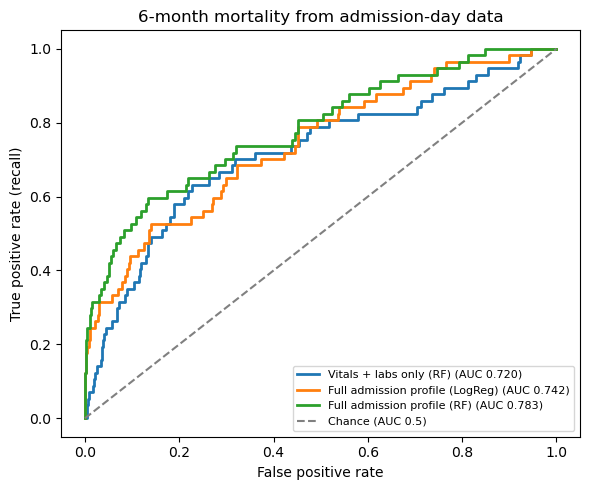

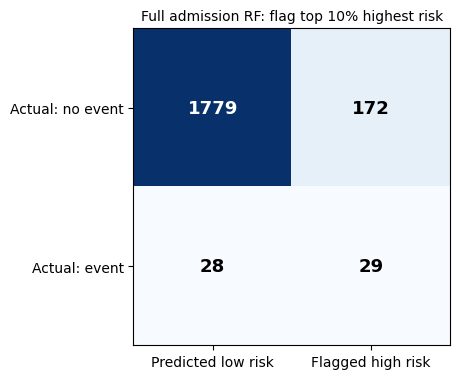

high_sensitivity_troponin     0.0415
heart_damage_level            0.0379
left_ventricle_size           0.0244
cystatin                      0.0229
severe_hf                     0.0223
brain_natriuretic_peptide     0.0216
neutrophil_count              0.0203
urea                          0.0190
neutrophil_ratio              0.0182
glomerular_filtration_rate    0.0175
creatine_kinase               0.0169
creatinine                    0.0154
potassium                     0.0152
d_dimer                       0.0135
eye_opening                   0.0125


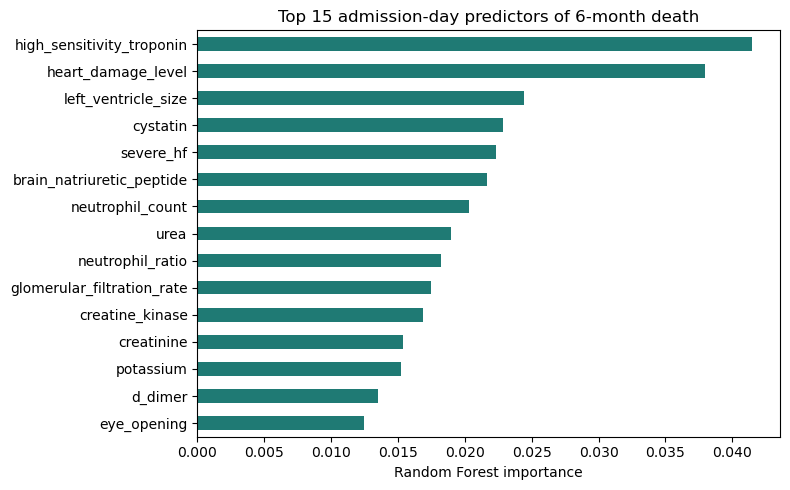


Observed 6-month death (%) by predicted-risk decile (1 = lowest):
{1: 0.0, 2: 1.0, 3: 1.0, 4: 1.5, 5: 2.0, 6: 2.0, 7: 1.5, 8: 2.0, 9: 3.0, 10: 14.4}


In [7]:
plot_roc({'Vitals + labs only (RF)': (y, p1), 'Full admission profile (LogReg)': (y, p2),
          'Full admission profile (RF)': (y, p3)}, '6-month mortality from admission-day data')
plot_confusion(y, p3, 'Full admission RF: flag top 10% highest risk')

# Which admission-day features drive the prediction? (Random Forest fitted on all patients)
rf_full = rforest().fit(X_adm, y)
imp = pd.Series(rf_full[-1].feature_importances_, index=X_adm.columns).sort_values(ascending=False).head(15)
print(imp.round(4).to_string())
fig, ax = plt.subplots(figsize=(8, 5))
imp[::-1].plot.barh(ax=ax, color='#1F7A74'); ax.set_xlabel('Random Forest importance')
ax.set_title('Top 15 admission-day predictors of 6-month death'); plt.tight_layout(); plt.show()

# Risk deciles: observed death rate in each tenth of predicted risk
dec = pd.qcut(pd.Series(p3).rank(method='first'), 10, labels=range(1, 11))
dec_rate = (y.groupby(dec.values).mean() * 100).round(1)
print("\nObserved 6-month death (%) by predicted-risk decile (1 = lowest):"); print(dec_rate.to_dict())


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
All three models (vitals + labs RF, full-profile Logistic Regression, full-profile RF) with the top-10% flag rule.

Q2 | Vitals + labs only (RF)
Decision rule: flag patients with predicted probability >= 0.136 (10.0% of patients flagged)
Accuracy 0.891 | Precision 0.100 | Recall 0.351 | F1 0.155 | ROC-AUC 0.720
Confusion matrix: TN = 1770, FP = 181, FN = 37, TP = 20
Classification report:
              precision    recall  f1-score   support

No event (0)      0.980     0.907     0.942      1951
   Event (1)      0.100     0.351     0.155        57

    accuracy                          0.891      2008
   macro avg      0.540     0.629     0.549      2008
weighted avg      0.955     0.891     0.920      2008

Q2 | Full admission profile (LogReg)
Decision rule: flag patients with predicted probability >= 0.498 (10.0% of patients flagged)
Accuracy 0.894 | Precision 0.114 | Recall 0.404 | F1 0.178 | ROC-AUC 0.742
Confusion matrix: TN = 1773, FP = 178, FN = 34, TP = 23
Classification report:
              precision    recall  f1-score   support

No event (0)      0.981     0.909     0.944      1951
   E

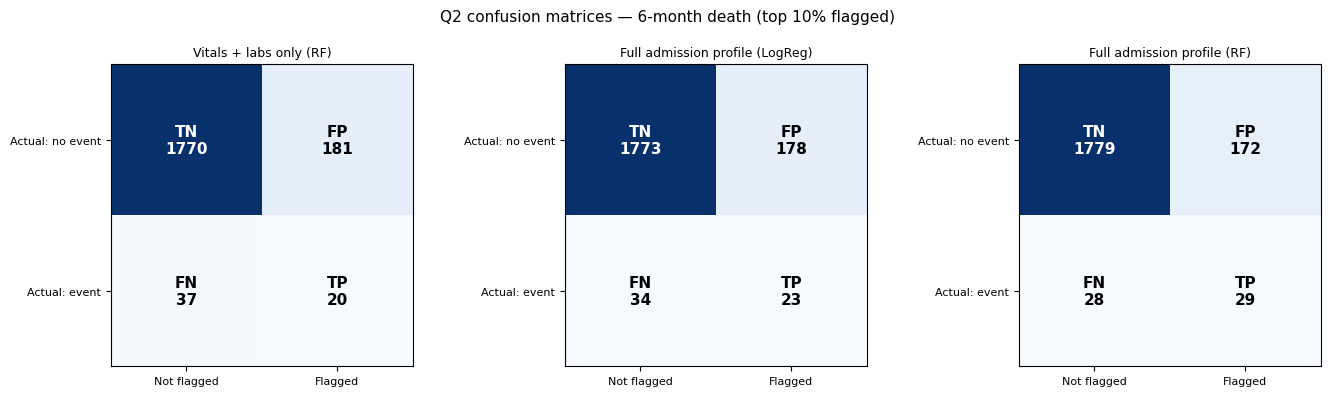

In [8]:
items = []
for name, p in [('Vitals + labs only (RF)', p1), ('Full admission profile (LogReg)', p2), ('Full admission profile (RF)', p3)]:
    items.append((name, df['death_6m'], full_report('Q2', name, df['death_6m'], p)))
cm_grid(items, 'Q2 confusion matrices — 6-month death (top 10% flagged)')


### How to read the chart
**Chart 1 — ROC curves:** one line per model. The y-axis is the share of deaths correctly flagged (recall), the x-axis the share of survivors wrongly flagged. The closer a line bends towards the **top-left corner**, the better; the **dashed diagonal** is guessing. The AUC in the legend summarises each line in one number.

**Chart 2 — confusion matrix:** shows what happens if we flag the **10% of patients with the highest predicted risk**. Rows are what really happened; columns are the model's decision.
- **Top-left (1,779):** survivors correctly left unflagged
- **Top-right (172):** survivors flagged — false alarms
- **Bottom-left (28):** deaths the model missed
- **Bottom-right (29):** deaths correctly flagged

**Chart 3 — feature importance:** the 15 admission-day features the Random Forest relied on most. A longer bar means the feature was used more often to separate patients who died from those who survived. It shows *how useful* a feature is, not whether it raises or lowers risk.

### Key Insights
- **Vitals and labs alone already give acceptable prediction (AUC 0.715)** — H1 is confirmed. Useful risk information exists before any treatment starts.
- **Adding the clinical assessment makes the model good (AUC 0.777)** and improves PR-AUC more than 3× (0.084 → 0.262) — H2 is confirmed. The Random Forest beats Logistic Regression (0.731), showing that the relationships are non-linear.
- **Flagging only 10% of patients catches 29 of 57 deaths (51%).** Of the 201 flagged patients, 14.4% die — **5× the average death rate**.
- **Risk is concentrated at the top:** observed death is 0–3% in the nine lowest risk deciles but **14.4% in the highest decile**.
- **Top predictors (H3 confirmed):** `high_sensitivity_troponin` (heart-muscle injury) and `heart_damage_level` (Killip class) lead by a clear margin, followed by left-ventricle size, `cystatin` (kidney), `severe_hf`, BNP (congestion), neutrophil count/ratio (inflammation/stress), urea, eGFR, creatine kinase, creatinine, potassium, D-dimer and eye opening. Risk comes from **heart injury + congestion + kidney failure + systemic stress**.

### Model accuracy
| Model | ROC-AUC (SD) | PR-AUC | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
| Vitals + labs only (RF) | 0.715 (0.005) | 0.084 | 0.891 | 0.100 | 0.351 | 0.155 |
| Full admission profile (LogReg) | 0.731 (0.024) | 0.224 | 0.894 | 0.114 | 0.404 | 0.178 |
| **Full admission profile (RF)** | **0.777 (0.007)** | **0.262** | **0.900** | **0.144** | **0.509** | **0.225** |

The main model is **good (AUC 0.777) and stable** (SD 0.007 across repeats). PR-AUC 0.262 is **9× chance (0.028)**. At the top-10% cut-off: precision 14.4% (5× the base rate), recall 50.9%. The 90% accuracy is inflated by the many survivors — precision/recall are the honest measures. With only 57 deaths, the model should be validated on new patients before clinical use.

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## 3. Can consciousness/responsiveness data (GCS and its components) at admission predict mortality, independent of cardiac severity markers?
### Reasoning
A drop in consciousness can mean the brain is not getting enough blood (low cardiac output), or that the patient has a severe systemic illness (infection, low oxygen, kidney or liver failure). The Glasgow Coma Scale (GCS) and its three parts — eye opening, verbal response and movement — are quick bedside scores recorded for every patient. The key question is whether GCS tells us something **new**, or whether it simply repeats what the cardiac severity grades already show. We compare three models: **severity only**, **GCS only**, and **severity + GCS**. The question asked about in-hospital death, but only **11 patients died in hospital** — far too few to train a model — so **28-day death (37 events)** is used as the early-mortality outcome.

### Hypothesis
- **H1:** Cardiac severity (NYHA, Killip, severe HF) predicts 28-day death well.
- **H2:** Adding GCS improves the prediction beyond severity — i.e., GCS carries independent information.
- **H3:** Among GCS components, a low eye-opening score will be the strongest warning sign.

### Features / Biomarkers used
- **Cardiac severity:** `heart_failure_severity` (NYHA), `heart_damage_level` (Killip), `severe_hf`
- **Consciousness:** `gcs` (total 3–15), `eye_opening` (1–4), `verbal_response` (1–5), `movement` (1–6), `consciousness` → `conscious_clear` (1 = Clear)
- **Outcome:** `death_28d` (37 deaths, 1.8%)

### Model used
**Logistic Regression** (median imputation → standardisation → L2 penalty C = 0.1, class-balanced), fitted on three feature sets. The combined model is also refitted on all patients to read its standardised coefficients.

### Why this model was chosen
- **Simple and transparent:** each feature gets one coefficient, so we can see exactly how much it raises or lowers risk.
- **Works well with few features** (here 1–8), where a complex model has nothing extra to learn and would only add noise.
- **Features are standardised**, so the coefficients are directly comparable with each other.
- **L2 regularisation (C = 0.1)** shrinks unstable coefficients — important because there are few events.
- **Class-balanced weighting** makes the rare deaths count as much as the many survivors.
- **Coefficients answer the "independent of" part of the question directly:** in the combined model each coefficient shows the effect of that feature *after* accounting for all the others.
- With only 37 events and 8 features, a complex model like Random Forest would overfit; the screening Random Forest gave a similar AUC (0.840), so the simpler model loses nothing.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [9]:
y28 = df['death_28d']
print("In-hospital deaths:", (df['hospitalization_outcome'] == 'Dead').sum(), "| 28-day deaths:", y28.sum())
ra, pa = evaluate('Cardiac severity only', logreg(), df[SEVERITY], y28)
rb, pb = evaluate('GCS components only', logreg(), df[GCS], y28)
rc, pc = evaluate('Cardiac severity + GCS', logreg(), df[SEVERITY + GCS], y28)
q3 = pd.DataFrame([ra, rb, rc]).set_index('Model')
print(q3.to_string())

# Coefficients of the combined model (standardised, so they are comparable)
m = logreg().fit(df[SEVERITY + GCS], y28)
coef = pd.Series(m[-1].coef_[0], index=SEVERITY + GCS).sort_values()
print("\nStandardised logistic-regression coefficients (combined model):"); print(coef.round(3).to_string())


In-hospital deaths: 11 | 28-day deaths: 37
                        Patients  Events  Event rate %  ROC-AUC  ROC-AUC SD  PR-AUC  Accuracy  Precision  Recall     F1
Model                                                                                                                  
Cardiac severity only       2008      37           1.8    0.845       0.008   0.139     0.905      0.119   0.649  0.201
GCS components only         2008      37           1.8    0.652       0.009   0.284     0.894      0.073   0.405  0.123
Cardiac severity + GCS      2008      37           1.8    0.843       0.007   0.370     0.905      0.119   0.649  0.201

Standardised logistic-regression coefficients (combined model):
eye_opening              -0.427
severe_hf                -0.176
conscious_clear          -0.077
gcs                       0.017
verbal_response           0.108
movement                  0.173
heart_failure_severity    0.326
heart_damage_level        1.307


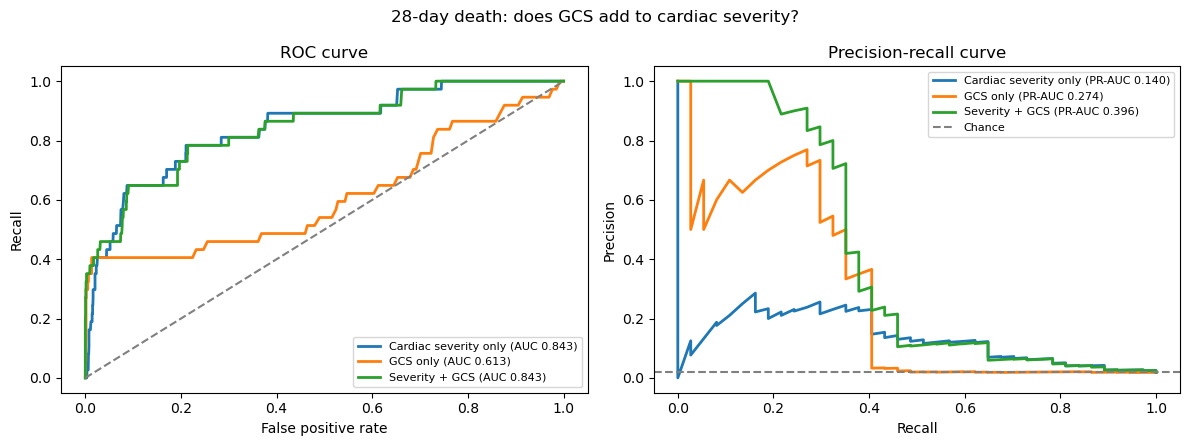

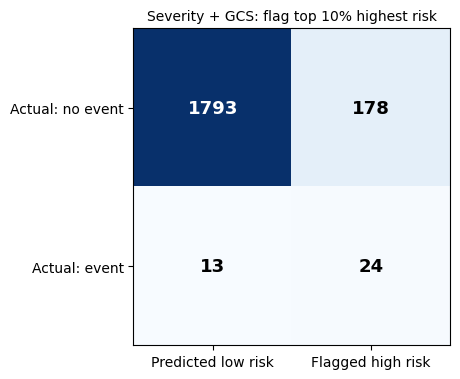

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for label, p in [('Cardiac severity only', pa), ('GCS only', pb), ('Severity + GCS', pc)]:
    fpr, tpr, _ = roc_curve(y28, p); ax[0].plot(fpr, tpr, lw=2, label=f"{label} (AUC {roc_auc_score(y28, p):.3f})")
    pr, rc_, _ = precision_recall_curve(y28, p); ax[1].plot(rc_, pr, lw=2, label=f"{label} (PR-AUC {average_precision_score(y28, p):.3f})")
ax[0].plot([0, 1], [0, 1], '--', color='grey'); ax[0].set_xlabel('False positive rate'); ax[0].set_ylabel('Recall'); ax[0].set_title('ROC curve'); ax[0].legend(fontsize=8)
ax[1].axhline(y28.mean(), ls='--', color='grey', label='Chance'); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision'); ax[1].set_title('Precision-recall curve'); ax[1].legend(fontsize=8)
fig.suptitle('28-day death: does GCS add to cardiac severity?'); plt.tight_layout(); plt.show()
plot_confusion(y28, pc, 'Severity + GCS: flag top 10% highest risk')


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
Severity only, GCS only and severity + GCS for 28-day death, top-10% flag rule.

Q3 | Cardiac severity only
Decision rule: flag patients with predicted probability >= 0.618 (10.1% of patients flagged)
Accuracy 0.905 | Precision 0.119 | Recall 0.649 | F1 0.201 | ROC-AUC 0.843
Confusion matrix: TN = 1793, FP = 178, FN = 13, TP = 24
Classification report:
              precision    recall  f1-score   support

No event (0)      0.993     0.910     0.949      1971
   Event (1)      0.119     0.649     0.201        37

    accuracy                          0.905      2008
   macro avg      0.556     0.779     0.575      2008
weighted avg      0.977     0.905     0.936      2008

Q3 | GCS components only
Decision rule: flag patients with predicted probability >= 0.395 (10.3% of patients flagged)
Accuracy 0.894 | Precision 0.073 | Recall 0.405 | F1 0.123 | ROC-AUC 0.613
Confusion matrix: TN = 1780, FP = 191, FN = 22, TP = 15
Classification report:
              precision    recall  f1-score   support

No event (0)      0.988     0.903     0.944      1971
   Event (1)      

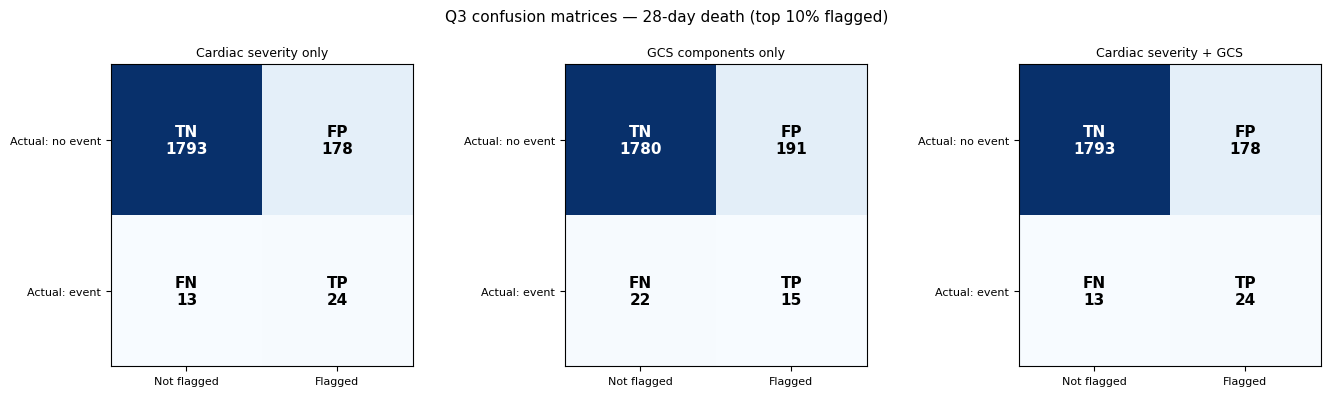

In [11]:
items = []
for name, p in [('Cardiac severity only', pa), ('GCS components only', pb), ('Cardiac severity + GCS', pc)]:
    items.append((name, y28, full_report('Q3', name, y28, p)))
cm_grid(items, 'Q3 confusion matrices — 28-day death (top 10% flagged)')


### How to read the chart
**Chart 1 — left panel, ROC curves:** one line per model (severity only, GCS only, severity + GCS). A line closer to the **top-left** separates patients who died from those who survived better; the diagonal is guessing.

**Chart 1 — right panel, precision-recall curves:** the x-axis is the share of deaths caught (recall), the y-axis the share of flagged patients who actually died (precision). The **dashed line** is the chance level (1.8%, the death rate). A line that stays **high on the left side** means the model's highest-risk patients really do die — this is where the difference between the models shows most clearly.

**Chart 2 — confusion matrix (severity + GCS, top 10% flagged):**
- **1,793** survivors correctly not flagged · **178** survivors flagged (false alarms)
- **13** deaths missed · **24** deaths correctly flagged

### Key Insights
- **This is the best-performing model in the analysis: AUC 0.843.** Flagging just 10% of patients catches **24 of 37 early deaths (65%)** — H1 is confirmed.
- **GCS adds independent information — but at the top of the risk scale** (H2 partly confirmed). ROC-AUC does not change (0.845 → 0.843), yet **PR-AUC almost triples (0.139 → 0.370)**. GCS does not help sort the average patient, but it sharply picks out the *very highest-risk* patients: in the precision-recall chart, the combined model's line stays far higher on the left.
- **GCS alone is weak (AUC 0.652)** because 98% of patients are fully alert — but when it *is* abnormal, it is a strong warning sign.
- **Killip class is the dominant predictor** (standardised coefficient **+1.31**), followed by NYHA class (+0.33).
- **Eye opening is the most important GCS component (coefficient −0.43)** — H3 is confirmed: the lower the eye-opening score, the higher the risk. The total GCS score adds almost nothing on top of its components (+0.02). The small negative coefficient for `severe_hf` (−0.18) reflects overlap with Killip class, not a protective effect.

### Model accuracy
| Model | ROC-AUC (SD) | PR-AUC | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
| Cardiac severity only | 0.845 (0.008) | 0.139 | 0.905 | 0.119 | 0.649 | 0.201 |
| GCS components only | 0.652 (0.009) | 0.284 | 0.894 | 0.073 | 0.405 | 0.123 |
| **Cardiac severity + GCS** | **0.843 (0.007)** | **0.370** | **0.905** | **0.119** | **0.649** | **0.201** |

The combined model is **good (AUC 0.843, "good" band 0.8–0.9)** and stable. Its PR-AUC (0.370) is **20× the chance level (0.018)** — the best precision-recall performance of all models. At the top-10% cut-off: recall 64.9%, precision 11.9% (6.5× the base rate). Because 28-day deaths are rare (37), the confidence in these numbers is limited and they should be re-checked on new data.

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## 4. Does heart failure subtype (heart_failure_type: Left/Right/Both) improve predictive accuracy for mortality when added to a model already containing LVEF (heart_pumping_efficiency) and NYHA/Killip grade?
### Reasoning
Heart failure subtype describes **which side of the heart is failing** — left, right or both (biventricular). It is recorded for every patient, whereas LVEF needs an echocardiogram and is missing for most. Biventricular failure is usually more advanced (both the lungs and the body are congested), so subtype may add information on top of LVEF and the severity grades. We fit a **base model** (LVEF + NYHA + Killip) and the **same model + subtype**, with two different algorithms, and compare the results. If subtype adds value, it should be kept in risk models; if not, the simpler model is enough.

### Hypothesis
- **H1:** Adding HF subtype increases the model's ROC-AUC for 6-month death.
- **H2:** Biventricular ("Both") failure carries higher risk than left- or right-sided failure alone.
- **H3:** Because LVEF is missing for most patients, subtype partly makes up for the missing echo information.

### Features / Biomarkers used
- **Base model:** `heart_pumping_efficiency` (LVEF %, recorded for only 635 of 2,008 patients; missing values filled with the median), `heart_failure_severity` (NYHA), `heart_damage_level` (Killip)
- **Added:** `heart_failure_type` → three 0/1 columns `hf_left`, `hf_right`, `hf_both` (Both 1,480; Left 477; Right 51 patients)
- **Outcome:** `death_6m` (57 deaths, 2.8%)

### Model used
**Logistic Regression** and **Random Forest** (both class-balanced), each fitted twice — without and with subtype — giving 4 models.

### Why this model was chosen
Two different algorithms are used on purpose, so the conclusion does not depend on one model's quirks:
- **Logistic Regression** tests whether subtype adds a simple, additive effect on risk (its strengths: transparent, stable with few features).
- **Random Forest** tests whether subtype matters through **interactions** — e.g., subtype mattering more for some Killip classes or LVEF levels than others — which Logistic Regression cannot capture.
- If both models agree, the finding is robust. Comparing **nested models** (the same features ± subtype) isolates the effect of subtype alone.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [ ]:
base = ['heart_pumping_efficiency', 'heart_failure_severity', 'heart_damage_level']   # LVEF + NYHA + Killip
subtype = ['hf_left', 'hf_right', 'hf_both']
y = df['death_6m']
print("LVEF (heart_pumping_efficiency) recorded for", df['heart_pumping_efficiency'].notna().sum(), "of", len(df), "patients (missing values imputed with the median)")
print("6-month death (%) by HF subtype:", (df.groupby('heart_failure_type')['death_6m'].mean() * 100).round(1).to_dict())
print("Patients by HF subtype:", df['heart_failure_type'].value_counts().to_dict(), "\n")
rows, preds = [], {}
for mname, mk in [('Logistic Regression', logreg), ('Random Forest', rforest)]:
    for fname, feats in [('LVEF + NYHA + Killip', base), ('+ HF subtype', base + subtype)]:
        res, p = evaluate(f"{mname} | {fname}", mk(), df[feats], y); rows.append(res); preds[f"{mname} | {fname}"] = p
q4 = pd.DataFrame(rows).set_index('Model')
print(q4[['Events', 'ROC-AUC', 'ROC-AUC SD', 'PR-AUC', 'Accuracy', 'Precision', 'Recall', 'F1']].to_string())


LVEF (heart_pumping_efficiency) recorded for 635 of 2008 patients (missing values imputed with the median)
6-month death (%) by HF subtype: {'Both': 3.1, 'Left': 2.3, 'Right': 0.0}
Patients by HF subtype: {'Both': 1480, 'Left': 477, 'Right': 51} 



In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
vals = q4['ROC-AUC'].values.reshape(2, 2); sds = q4['ROC-AUC SD'].values.reshape(2, 2)
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, vals[:, 0], w, yerr=sds[:, 0], capsize=4, label='LVEF + NYHA + Killip', color='#8A8A8A')
b2 = ax.bar(x + w/2, vals[:, 1], w, yerr=sds[:, 1], capsize=4, label='+ HF subtype', color='#1F7A74')
ax.bar_label(b1, fmt='%.3f', padding=6); ax.bar_label(b2, fmt='%.3f', padding=6)
ax.set_xticks(x); ax.set_xticklabels(['Logistic Regression', 'Random Forest']); ax.set_ylim(0.5, 0.9)
ax.set_ylabel('Cross-validated ROC-AUC'); ax.set_title('6-month death: does HF subtype add to LVEF + NYHA + Killip?'); ax.legend()
plt.tight_layout(); plt.show()
plot_roc({k: (y, v) for k, v in preds.items()}, '6-month death: base model vs + HF subtype')


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
Base model (LVEF + NYHA + Killip) and base + HF subtype, for both algorithms, top-10% flag rule.

In [ ]:
items = []
for name, p in preds.items():
    items.append((name, df['death_6m'], full_report('Q4', name, df['death_6m'], p)))
cm_grid(items, 'Q4 confusion matrices — 6-month death (top 10% flagged)')


### How to read the chart
**Chart 1 — bar chart:** two groups (Logistic Regression and Random Forest). In each group, the **grey bar** is the base model (LVEF + NYHA + Killip) and the **teal bar** is the same model + HF subtype. The number on each bar is the ROC-AUC, and the **small black error line** shows the variation across the cross-validation repeats (± 1 SD). If the teal bar is higher than the grey bar and the error lines do not overlap, subtype genuinely improves the model. The y-axis starts at 0.5 (chance level) to make the differences visible.

**Chart 2 — ROC curves:** all four models on one chart. Lines closer to the **top-left** are better; the diagonal is guessing.

### Key Insights
- **HF subtype gives a small but consistent gain in ranking ability** — H1 is confirmed. ROC-AUC rises by **+0.013** with Logistic Regression (0.746 → 0.759) and **+0.036** with Random Forest (0.742 → **0.778**). The error bars are very small (SD ≤ 0.008), so the gain is not random noise.
- **The larger gain in Random Forest** shows that subtype works mainly through interactions with the severity grades, not as a simple additive effect.
- **It does not improve precision.** PR-AUC stays flat or drops slightly (LogReg 0.150 → 0.128; RF 0.109 → 0.106), and precision/recall at the top-10% cut-off are unchanged. Subtype helps sort low- and medium-risk patients, not pick out the very highest-risk ones.
- **Biventricular failure is the riskiest subtype** (6-month death 3.1%) vs left-sided (2.3%) and right-sided (0 deaths among 51) — H2 is confirmed.
- **LVEF is missing for 68% of patients**, so the base model relies mostly on NYHA and Killip. Subtype is recorded for everyone and partly fills this gap — H3 is supported.

### Model accuracy
| Model | ROC-AUC (SD) | PR-AUC | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
| LogReg: LVEF + NYHA + Killip | 0.746 (0.008) | 0.150 | 0.891 | 0.100 | 0.351 | 0.155 |
| LogReg: + HF subtype | 0.759 (0.003) | 0.128 | 0.892 | 0.104 | 0.368 | 0.163 |
| RF: LVEF + NYHA + Killip | 0.742 (0.005) | 0.109 | 0.894 | 0.114 | 0.404 | 0.178 |
| **RF: + HF subtype** | **0.778 (0.002)** | 0.106 | 0.894 | 0.114 | 0.404 | 0.178 |

The best model (RF + subtype) reaches **AUC 0.778 — close to "good"** — and is extremely stable (SD 0.002). Precision (11.4%) is 4× the base rate and recall is 40.4%. The improvement from subtype is real for ranking but modest in size.

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## 5. Can a model built on this single-center Sichuan cohort reliably separate high-risk vs. low-risk patients using only variables that would be available in a typical Chinese hospital EHR at admission — and how does model performance compare between the elderly (69+) majority and the smaller younger subgroup?
### Reasoning
This dataset was collected to understand heart failure in the Chinese population. A risk model is only safe to use if it works for the patients it will be applied to. Because **73% of patients are 69 or older**, a model can look good overall while performing poorly for younger patients — it simply learns mostly from the elderly. We take the full admission-day mortality model from Question 2 (built only from standard EHR fields recorded on admission), check its overall performance, and then check it **separately for elderly (69+) and younger (< 69) patients**, with confidence intervals to show how certain each result is.

### Hypothesis
- **H1:** Using routine admission EHR data, the model separates high- and low-risk patients well overall (AUC > 0.75).
- **H2:** The model performs better in the elderly majority than in the younger subgroup, because it has far more elderly deaths to learn from (42 vs 15).

### Features / Biomarkers used
- **Features:** the full admission-day EHR profile — demography, 18 comorbidity features, cardiac function (NYHA, Killip, severe HF, HF type, echo), vitals, GCS components, 88 routine labs, emergency admission and ward
- **Subgroups:** **Elderly** = `age_category` 69–79, 79–89, 89–110 (1,462 patients, 42 deaths); **Younger** = below 69 (546 patients, 15 deaths)
- **Outcome:** `death_6m`

### Model used
**Random Forest** (300 trees, `min_samples_leaf=5`, class-balanced) trained on all patients with repeated stratified 5-fold cross-validation. The cross-validated risk scores are then evaluated separately in each age group, and **1,000 bootstrap resamples** give a 95% confidence interval for each group's AUC.

### Why this model was chosen
- **Handles many features at once** (up to 130 columns) without needing to pick them by hand.
- **Captures non-linear effects and interactions** — e.g., risk that jumps only at Killip class 4, or high troponin being dangerous mainly when kidney function is poor — which a straight-line model misses.
- **Robust to outliers and skewed lab values** (troponin, BNP and creatinine are very skewed), because trees split on thresholds rather than on raw magnitudes.
- **Class-balanced weighting** (`class_weight='balanced_subsample'`) stops the model from simply predicting "survives" for everyone when deaths are only 2.8%.
- `min_samples_leaf=5` and 300 trees keep it from memorising individual patients (overfitting) in a small dataset.
- Gives a **feature-importance ranking**, so the result can be explained.
- It is the **same model as the best model in Question 2**, so this question directly tests how reliable that model is for different kinds of patients.
- **One model for everyone, evaluated by subgroup** mirrors real use: a hospital would run one model on all admissions, not a separate one per age group. Training separate models on 546 younger patients with 15 deaths would be far too unstable.
- **Bootstrap confidence intervals** show how much each subgroup AUC could vary by chance — essential for the small younger group.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [ ]:
X_adm = df[DEMO + COMOR + CARD + VITALS + GCS + LABS + ADMIT]
y = df['death_6m']
res_all, p_all = evaluate('Full admission profile (Random Forest)', rforest(), X_adm, y)
elderly = (df['age_mid'] >= 69).values          # age groups 69-79, 79-89, 89-110
rows = []
for name, mask in [('All patients', np.ones(len(df), bool)), ('Elderly (69+)', elderly), ('Younger (<69)', ~elderly)]:
    yy, pp = y[mask], p_all[mask]
    flag = pp >= np.quantile(p_all, 0.90)       # same top-10% cut-off as the whole cohort
    rows.append({'Group': name, 'Patients': int(mask.sum()), 'Deaths': int(yy.sum()), 'Death rate %': round(yy.mean() * 100, 1),
                 'ROC-AUC': round(roc_auc_score(yy, pp), 3), 'PR-AUC': round(average_precision_score(yy, pp), 3),
                 'Flagged %': round(flag.mean() * 100, 1), 'Precision': round(yy[flag].mean(), 3) if flag.sum() else np.nan,
                 'Recall': round(yy[flag].sum() / yy.sum(), 3)})
q5 = pd.DataFrame(rows).set_index('Group')
print(q5.to_string())

# Bootstrap 95% confidence interval for each subgroup AUC
rng = np.random.default_rng(42)
for name, mask in [('Elderly (69+)', elderly), ('Younger (<69)', ~elderly)]:
    yy, pp = y[mask].values, p_all[mask]; boots = []
    for _ in range(1000):
        idx = rng.integers(0, len(yy), len(yy))
        if yy[idx].sum() > 0: boots.append(roc_auc_score(yy[idx], pp[idx]))
    print(f"{name}: AUC 95% CI {np.percentile(boots, 2.5):.3f} - {np.percentile(boots, 97.5):.3f}")


In [ ]:
plot_roc({'All patients': (y, p_all), 'Elderly (69+)': (y[elderly], p_all[elderly]),
          'Younger (<69)': (y[~elderly], p_all[~elderly])}, '6-month mortality model: elderly vs younger')


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
The same Random Forest model is evaluated for all patients and for each age group. The **same cut-off** (top 10% of risk in the whole cohort) is applied to every group, as it would be in real use.

In [ ]:
thr_all = np.quantile(p_all, 0.90)
items = []
for name, mask in [('All patients', np.ones(len(df), bool)), ('Elderly (69+)', elderly), ('Younger (<69)', ~elderly)]:
    yy = df['death_6m'].values[mask]
    items.append((name, yy, full_report('Q5', name, yy, p_all[mask], thr=thr_all)))
cm_grid(items, 'Q5 confusion matrices — 6-month death by age group (same cut-off)')


### How to read the chart
**ROC curves by age group:** three lines from the same model — **all patients**, **elderly (69+)** and **younger (< 69)**. The y-axis is the share of deaths correctly flagged, the x-axis the share of survivors wrongly flagged. A line bending towards the **top-left** means the model separates that group well; a line close to the **dashed diagonal** means it is little better than guessing for that group. Compare the elderly and younger lines: the gap between them shows how much less reliable the model is for younger patients. The younger line is more jagged because it is built from only 15 deaths.

### Key Insights
- **Overall, the model reliably separates high- and low-risk patients (AUC 0.783)** using only standard admission EHR data — H1 is confirmed.
- **It works best for the elderly majority (AUC 0.816 — "good")** — H2 is confirmed. Flagging the top 10% of risk catches **57% of elderly deaths**, with 15.2% of flagged elderly patients dying (5× their death rate).
- **It is noticeably weaker for younger patients (AUC 0.694 — only "fair")**, catching just **33% of their deaths**.
- **The younger result is also much less certain:** its 95% confidence interval is very wide (**0.537–0.834**) compared with the elderly (**0.738–0.884**). With only 15 younger deaths, the true performance could be anywhere from barely-better-than-chance to good.
- The death rates are almost the same (2.9% vs 2.7%), so the difference is **not** because younger patients rarely die — it is because the model learned mostly from elderly patients.

### Model accuracy
| Group | Patients | Deaths | ROC-AUC (95% CI) | PR-AUC | Flagged % | Precision | Recall |
|---|---|---|---|---|---|---|---|
| All patients | 2,008 | 57 | **0.783** | 0.299 | 10.0 | 0.144 | 0.509 |
| **Elderly (69+)** | 1,462 | 42 | **0.816** (0.738–0.884) | **0.352** | 10.8 | **0.152** | **0.571** |
| Younger (< 69) | 546 | 15 | 0.694 (0.537–0.834) | 0.220 | 7.9 | 0.116 | 0.333 |

For the elderly, the model is **good and reliable** (AUC 0.816; PR-AUC 12× chance). For younger patients it is only **fair and uncertain**. The model should be used with confidence for patients aged 69+, and with caution — alongside clinical judgement — for younger patients. External validation in other Chinese hospitals is needed before wider use.

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## 6. Which single feature category (demography, comorbidities, cardiac function, labs, or vitals) contributes the most predictive power for 6-month mortality, based on feature importance from a trained model?
### Reasoning
The dataset combines 7 source tables, and collecting each kind of data costs time and money. If one category carries most of the predictive power, future data collection and bedside risk scores can focus on it. Simply reading the model's feature-importance chart is not enough, because categories with many columns (labs have 88) automatically collect a large share of importance. So we measure each category's contribution **three different ways** and compare them.

### Hypothesis
- **H1:** Cardiac function (severity grades, HF type, echo) contributes the most predictive power for 6-month death.
- **H2:** Labs will look most important by raw feature-importance share only because they have the most columns — their true added value will be smaller.
- **H3:** Demography adds little once clinical information is known (consistent with Question 1, where age alone was useless).

### Features / Biomarkers used
- **Six categories:** Demography (5 features), Comorbidities (18), Cardiac function (10), Vitals (8), Consciousness/GCS (5), Labs (88)
- **Outcome:** `death_6m` (57 deaths)
- **Three measures of contribution:**
  1. **AUC alone** — a model using *only* that category (how much information it holds by itself)
  2. **AUC lost when removed** — full model minus that category (how much *unique* information it adds that no other category replaces)
  3. **Share of Random Forest importance** — the usual feature-importance view, summed per category

### Model used
**Random Forest** (300 trees, class-balanced) — 13 models in total: 1 full model, 6 single-category models and 6 "drop-one-category" models, each tested with repeated stratified 5-fold cross-validation.

### Why this model was chosen
- **Handles many features at once** (up to 130 columns) without needing to pick them by hand.
- **Captures non-linear effects and interactions** — e.g., risk that jumps only at Killip class 4, or high troponin being dangerous mainly when kidney function is poor — which a straight-line model misses.
- **Robust to outliers and skewed lab values** (troponin, BNP and creatinine are very skewed), because trees split on thresholds rather than on raw magnitudes.
- **Class-balanced weighting** (`class_weight='balanced_subsample'`) stops the model from simply predicting "survives" for everyone when deaths are only 2.8%.
- `min_samples_leaf=5` and 300 trees keep it from memorising individual patients (overfitting) in a small dataset.
- Gives a **feature-importance ranking**, so the result can be explained.
- **The same algorithm is used for all 13 models**, so any difference in AUC comes only from the features, not from the model.
- **Single-category and drop-one-category tests** correct the known bias of Random Forest importance towards categories with many or continuous features, giving a fair comparison.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [ ]:
groups = {'Demography': DEMO, 'Comorbidities': COMOR, 'Cardiac function': CARD,
          'Vitals': VITALS, 'Consciousness (GCS)': GCS, 'Labs': LABS}
y = df['death_6m']
all_feats = [f for g in groups.values() for f in g]
full_res, _ = evaluate('All categories', rforest(), df[all_feats], y, reps=2)
rows = []
for gname, feats in groups.items():
    alone, _ = evaluate(gname, rforest(), df[feats], y, reps=2)
    rest = [f for f in all_feats if f not in feats]
    without, _ = evaluate('without ' + gname, rforest(), df[rest], y, reps=2)
    rows.append({'Category': gname, 'Features': len(feats), 'AUC alone': alone['ROC-AUC'],
                 'AUC without it': without['ROC-AUC'], 'AUC lost when removed': round(full_res['ROC-AUC'] - without['ROC-AUC'], 3)})
q6 = pd.DataFrame(rows).set_index('Category').sort_values('AUC alone', ascending=False)
print("All categories together: ROC-AUC", full_res['ROC-AUC'], "| PR-AUC", full_res['PR-AUC'])
print(q6.to_string())

# Share of Random Forest importance by category
rf_all = rforest().fit(df[all_feats], y)
imp = pd.Series(rf_all[-1].feature_importances_, index=all_feats)
share = pd.Series({g: imp[f].sum() for g, f in groups.items()}).sort_values(ascending=False)
print("\nShare of total Random Forest importance (%):"); print((share * 100).round(1).to_string())


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
q6['AUC alone'].sort_values().plot.barh(ax=ax[0], color='#13294B')
ax[0].axvline(0.5, ls='--', color='grey'); ax[0].set_xlim(0.4, 0.85); ax[0].set_xlabel('ROC-AUC using only this category')
ax[0].set_title('Predictive power of each category on its own')
for i, v in enumerate(q6['AUC alone'].sort_values()): ax[0].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=8)
(share * 100).sort_values().plot.barh(ax=ax[1], color='#1F7A74')
ax[1].set_xlabel('% of total Random Forest importance'); ax[1].set_title('Share of importance in the combined model')
for i, v in enumerate((share * 100).sort_values()): ax[1].text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=8)
plt.tight_layout(); plt.show()


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
The full model (all six categories) and the best single-category model (cardiac function only) are re-scored here with the top-10% flag rule.

In [ ]:
_, p6_all = evaluate('All categories', rforest(), df[all_feats], df['death_6m'], reps=2)
_, p6_card = evaluate('Cardiac function only', rforest(), df[CARD], df['death_6m'], reps=2)
items = []
for name, p in [('All six categories (RF)', p6_all), ('Cardiac function only (RF)', p6_card)]:
    items.append((name, df['death_6m'], full_report('Q6', name, df['death_6m'], p)))
cm_grid(items, 'Q6 confusion matrices — 6-month death (top 10% flagged)')


### How to read the chart
**Left panel — "Predictive power of each category on its own":** each bar is the ROC-AUC of a model that uses **only** that category. The **dashed line at 0.5** is chance. A longer bar means the category holds more information about death by itself.

**Right panel — "Share of importance in the combined model":** how the full Random Forest's total importance (100%) is split between categories. A longer bar means the model used that category's features more often. **Read this panel with care:** it favours categories with many columns (labs: 88), so compare it with the left panel and the "AUC lost when removed" column in the table.

### Key Insights
- **Cardiac function is the most valuable category — H1 is confirmed.** With just 10 features it reaches **AUC 0.768 on its own** (almost as good as the full model's 0.798), and removing it causes the **largest drop in performance (−0.041)**.
- **Labs look dominant by importance share (76.1%), but this is misleading — H2 is confirmed.** Labs alone reach only 0.699, and **removing all 88 labs actually slightly improves the model (0.798 → 0.811)**. Their key information (kidney function, heart injury) overlaps with the cardiac and comorbidity categories, and the many extra columns add noise.
- **Comorbidities (−0.024) and consciousness/GCS (−0.013)** add unique information that no other category replaces, even though they are weak on their own (0.629 and 0.590).
- **Demography and vitals add essentially nothing** once the other categories are known (removal changes AUC by ≤ 0.001) — H3 is confirmed.
- **The two views disagree for a reason:** importance share measures how often the model *uses* a feature, while the removal test measures how much *unique* information it brings. The removal test is the fairer answer to "which category matters most".

### Model accuracy
**Full model (all six categories): ROC-AUC 0.798, PR-AUC 0.277** (**10× the chance level of 0.028**).

| Category | Features | AUC alone | AUC without it | AUC lost when removed | Share of RF importance |
|---|---|---|---|---|---|
| **Cardiac function** | 10 | **0.768** | 0.757 | **0.041** | 9.6% |
| Labs | 88 | 0.699 | 0.811 | −0.013 | 76.1% |
| Vitals | 8 | 0.656 | 0.799 | −0.001 | 3.9% |
| Comorbidities | 18 | 0.629 | 0.774 | 0.024 | 2.4% |
| Consciousness (GCS) | 5 | 0.590 | 0.785 | 0.013 | 5.9% |
| Demography | 5 | 0.563 | 0.799 | −0.001 | 2.1% |

The full model is **close to "good" (AUC 0.798)**. The cardiac-function model alone (AUC 0.768) is nearly as accurate with only 10 features, which makes it the best candidate for a simple bedside score. Each model here was tested with 2 repeats of 5-fold cross-validation (13 models in total), so differences smaller than about ±0.01 should be treated as noise.

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## 7. How far ahead can admission-day data predict death — within 28 days, 3 months or 6 months?
### Reasoning
Question 2 showed that 6-month death can be predicted from admission data with AUC 0.777. But a patient's condition on admission should say more about what happens in the **next few weeks** than about what happens half a year later, when new events (infections, falls, new heart attacks, stopping medicines) have had time to occur. Knowing **how long the admission snapshot stays informative** tells the team how long an admission risk score can be trusted, and when it needs to be refreshed with new information. We train the same model on the same admission features for three outcomes: death within **28 days**, **3 months** and **6 months**.

### Hypothesis
- **H1:** Admission data predict short-term death better than long-term death — prediction quality falls as the time horizon gets longer.
- **H2:** Short-term death is driven mainly by acute markers (Killip class, troponin, severe HF, consciousness).
- **H3:** Random Forest will beat Logistic Regression, especially for short-term death, because acute risk depends on thresholds and combinations (e.g., Killip 4 *and* reduced consciousness).

### Features / Biomarkers used
- **Features (identical for all three outcomes):** full admission-day profile — demography, 18 comorbidity features, cardiac function (NYHA, Killip, `severe_hf`, HF type, LVEF and echo measures), vitals, GCS components, 88 routine labs, emergency admission and ward
- **Outcomes:** `death_28d` (37 deaths, 1.8%), `death_3m` (42 deaths, 2.1%), `death_6m` (57 deaths, 2.8%). The deaths are nested: every 28-day death is also a 3-month and 6-month death.

### Model used
**Random Forest** (300 trees, `min_samples_leaf=5`, class-balanced) — main model; **Logistic Regression** (L2, C = 0.1, class-balanced) — comparison. 6 models in total (2 algorithms × 3 horizons).

### Why this model was chosen
**Random Forest (main model):**
- **Handles many features at once** (up to 130 columns) without needing to pick them by hand.
- **Captures non-linear effects and interactions** — e.g., risk that jumps only at Killip class 4, or high troponin being dangerous mainly when kidney function is poor — which a straight-line model misses.
- **Robust to outliers and skewed lab values** (troponin, BNP and creatinine are very skewed), because trees split on thresholds rather than on raw magnitudes.
- **Class-balanced weighting** (`class_weight='balanced_subsample'`) stops the model from simply predicting "survives" for everyone when deaths are only 2.8%.
- `min_samples_leaf=5` and 300 trees keep it from memorising individual patients (overfitting) in a small dataset.
- Gives a **feature-importance ranking**, so the result can be explained.

**Using the same features and model for every horizon** means any change in accuracy comes only from the time horizon, not from the model — this is what makes the comparison fair. Logistic Regression is included to show whether the relationships are simple (straight-line) or need a non-linear model.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [ ]:
X_adm = df[DEMO + COMOR + CARD + VITALS + GCS + LABS + ADMIT]     # full admission-day profile (same as Question 2)
horizons = {'death_28d': '28 days', 'death_3m': '3 months', 'death_6m': '6 months'}
rows, preds = [], {}
for tgt, lab in horizons.items():
    r, p = evaluate(f'Death within {lab} (Random Forest)', rforest(), X_adm, df[tgt]); rows.append(r); preds[lab] = (df[tgt], p)
    r, _ = evaluate(f'Death within {lab} (Logistic Regression)', logreg(), X_adm, df[tgt]); rows.append(r)
q7 = pd.DataFrame(rows).set_index('Model')
print(q7.to_string())


In [ ]:
plot_roc({f'Death within {k}': v for k, v in preds.items()}, 'How far ahead can admission data predict death? (Random Forest)')

rf_rows = q7[q7.index.str.contains('Random Forest')]
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(3); w = 0.35
b1 = ax.bar(x - w/2, rf_rows['ROC-AUC'], w, label='ROC-AUC', color='#13294B')
b2 = ax.bar(x + w/2, rf_rows['PR-AUC'], w, label='PR-AUC', color='#1F7A74')
ax.bar_label(b1, fmt='%.3f'); ax.bar_label(b2, fmt='%.3f')
ax.scatter(x + w/2, rf_rows['Event rate %'] / 100, marker='_', s=900, color='#B3261E', zorder=3, label='PR-AUC chance level (death rate)')
ax.set_xticks(x); ax.set_xticklabels(['28 days', '3 months', '6 months']); ax.set_ylim(0, 1)
ax.set_ylabel('Score'); ax.set_title('Prediction quality by time horizon (Random Forest)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Top predictors of 3-month death
rf3 = rforest().fit(X_adm, df['death_3m'])
imp3 = pd.Series(rf3[-1].feature_importances_, index=X_adm.columns).sort_values(ascending=False).head(12)
print("Top 12 predictors of 3-month death:"); print(imp3.round(4).to_string())


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
Random Forest and Logistic Regression for each time horizon (28 days, 3 months, 6 months), top-10% flag rule.

In [ ]:
items = []
for tgt, lab in horizons.items():
    items.append((f'{lab} | Random Forest', df[tgt], full_report('Q7', f'Death within {lab} | Random Forest', df[tgt], preds[lab][1])))
for tgt, lab in horizons.items():
    _, p_lr = evaluate(lab, logreg(), X_adm, df[tgt])
    items.append((f'{lab} | Logistic Regression', df[tgt], full_report('Q7', f'Death within {lab} | Logistic Regression', df[tgt], p_lr)))
cm_grid(items, 'Q7 confusion matrices by time horizon (top 10% flagged)')


### How to read the chart
**Chart 1 — ROC curves by horizon:** one line per outcome (28 days, 3 months, 6 months). The y-axis is the share of deaths caught, the x-axis the share of survivors wrongly flagged. The line that bends **closest to the top-left corner** is the horizon the model predicts best; the dashed diagonal is guessing.

**Chart 2 — prediction quality by horizon:** for each horizon, the **navy bar** is ROC-AUC (ranking ability) and the **teal bar** is PR-AUC (precision across thresholds). The **short red line** on each teal bar marks the chance level for PR-AUC (the death rate) — the higher the teal bar sits above the red line, the better the model finds the actual deaths.

### Key Insights
- **Admission data predict early death extremely well: AUC 0.902 for 28-day death ("excellent")**, 0.877 for 3 months, falling to **0.777 for 6 months** — H1 is confirmed.
- **Flagging the top 10% at admission catches 68% of deaths within 28 days** (25 of 37) and **67% within 3 months** (28 of 42), vs 51% within 6 months.
- **The 15 deaths between 3 and 6 months are much harder to predict** — they are driven by events after discharge that the admission snapshot cannot see. An admission risk score is reliable for about **3 months** and should be refreshed after that (e.g., at the first follow-up visit).
- **PR-AUC stays 10–16× above chance at every horizon** (0.286, 0.313, 0.262 vs death rates of 1.8–2.8%).
- **Top predictors of 3-month death are acute markers — H2 is confirmed:** Killip class (`heart_damage_level`) by a clear margin, then troponin, `severe_hf`, cystatin C and urea (kidney), hydroxybutyrate dehydrogenase (tissue injury), potassium, neutrophil count (stress/inflammation), and **three consciousness features (GCS, eye opening, movement)**.
- **Random Forest clearly beats Logistic Regression** for short-term death (0.902 vs 0.771 at 28 days) — H3 is confirmed: acute risk depends on thresholds and combinations that a straight-line model misses.

### Model accuracy
| Model | Deaths | ROC-AUC (SD) | PR-AUC | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|---|
| **28-day death — Random Forest** | 37 | **0.902 (0.009)** | 0.286 | 0.906 | 0.124 | **0.676** | 0.210 |
| 28-day death — Logistic Regression | 37 | 0.771 (0.030) | 0.207 | 0.904 | 0.114 | 0.622 | 0.193 |
| **3-month death — Random Forest** | 42 | **0.877 (0.007)** | **0.313** | 0.907 | 0.139 | **0.667** | 0.230 |
| 3-month death — Logistic Regression | 42 | 0.815 (0.012) | 0.244 | 0.902 | 0.114 | 0.548 | 0.189 |
| 6-month death — Random Forest | 57 | 0.777 (0.007) | 0.262 | 0.900 | 0.144 | 0.509 | 0.225 |
| 6-month death — Logistic Regression | 57 | 0.731 (0.024) | 0.224 | 0.894 | 0.114 | 0.404 | 0.178 |

The 28-day model is **excellent (AUC 0.902)** and the 3-month model **good (0.877)** — the strongest models in this notebook. Both are stable (SD < 0.01). Precision (12–14%) is 5–7× the death rate. Because there are only 37–42 events, these numbers should be confirmed on new patients before clinical use.

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## 8. Can we flag reduced ejection fraction (HFrEF, LVEF < 40%) at admission — before the echo is done — using routine bedside data?
### Reasoning
Whether a patient has **HFrEF** (a weak pump, LVEF < 40%) decides treatment: the proven life-saving heart-failure medicines (beta-blockers, ACE inhibitors/ARBs/ARNI, MRAs, SGLT2 inhibitors) work mainly in HFrEF. But LVEF needs an echocardiogram, and in this dataset **only 635 of 2,008 patients (32%) have an LVEF recorded**. If routine admission data can flag likely HFrEF, those patients can be **prioritised for an early echo** and for starting guideline therapy sooner. We train the model on the 635 patients who have a measured LVEF (so we know the true answer) using **no echo measurements at all** as features.

### Hypothesis
- **H1:** Routine admission data (without echo) can identify HFrEF with good discrimination (AUC > 0.74).
- **H2:** BNP (cardiac wall stress) and troponin (heart-muscle injury) will be the strongest predictors; HFrEF patients will have lower blood pressure and be more often male.
- **H3:** A short list of about 10 bedside features will perform almost as well as the full model — making it practical at the bedside.

### Features / Biomarkers used
- **Full model (no echo):** demography, 18 comorbidity features, NYHA class, Killip class, `severe_hf`, HF type (left/right/both), vitals, GCS components, 88 routine labs
- **10-feature bedside model:** `brain_natriuretic_peptide`, `high_sensitivity_troponin`, `sbp`, `pulse`, sex (`male`), NYHA class, Killip class, HF type (3 columns)
- **Excluded on purpose:** `heart_pumping_efficiency`, `left_ventricle_size`, `mitral_valve_ems`, `pulmonary_velocity` and all other echo measures
- **Outcome:** HFrEF = `heart_pumping_efficiency` < 40% (132 of 635 patients, 20.8%)

### Model used
- **Random Forest** (300 trees, class-balanced) on the full no-echo data
- **Logistic Regression** (L2, C = 0.1, class-balanced) on the 10 bedside features
- Accuracy/precision/recall are for flagging the **top 20%** (about the HFrEF rate)

### Why this model was chosen
**Random Forest** for the full data:
- **Handles many features at once** (up to 130 columns) without needing to pick them by hand.
- **Captures non-linear effects and interactions** — e.g., risk that jumps only at Killip class 4, or high troponin being dangerous mainly when kidney function is poor — which a straight-line model misses.
- **Robust to outliers and skewed lab values** (troponin, BNP and creatinine are very skewed), because trees split on thresholds rather than on raw magnitudes.
- **Class-balanced weighting** (`class_weight='balanced_subsample'`) stops the model from simply predicting "survives" for everyone when deaths are only 2.8%.
- `min_samples_leaf=5` and 300 trees keep it from memorising individual patients (overfitting) in a small dataset.
- Gives a **feature-importance ranking**, so the result can be explained.

**Logistic Regression** for the short bedside set:
- **Simple and transparent:** each feature gets one coefficient, so we can see exactly how much it raises or lowers risk.
- **Works well with few features** (here 1–8), where a complex model has nothing extra to learn and would only add noise.
- **Features are standardised**, so the coefficients are directly comparable with each other.
- **L2 regularisation (C = 0.1)** shrinks unstable coefficients — important because there are few events.
- **Class-balanced weighting** makes the rare deaths count as much as the many survivors.
- A 10-feature logistic model can be turned into a simple **points score or spreadsheet formula** for the ward, which a Random Forest cannot.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [ ]:
ech = df[df['heart_pumping_efficiency'].notna()].copy()             # patients with a measured LVEF (the "answer key")
y8 = (ech['heart_pumping_efficiency'] < 40).astype(int)             # HFrEF = LVEF < 40%
NO_ECHO_CARD = ['heart_failure_severity', 'heart_damage_level', 'severe_hf', 'hf_left', 'hf_right', 'hf_both']   # no echo measurements
X8 = ech[DEMO + COMOR + NO_ECHO_CARD + VITALS + GCS + LABS]
SMALL = ['brain_natriuretic_peptide', 'high_sensitivity_troponin', 'sbp', 'pulse', 'male',
         'heart_failure_severity', 'heart_damage_level', 'hf_left', 'hf_right', 'hf_both']
print("Patients with LVEF:", len(ech), "| HFrEF (LVEF < 40%):", y8.sum(), f"({y8.mean()*100:.1f}%)")
r1, p8_rf = evaluate('Random Forest | full admission data (no echo)', rforest(), X8, y8, top_frac=0.2)
r2, p8_lr = evaluate('Logistic Regression | 10 bedside features', logreg(), ech[SMALL], y8, top_frac=0.2)
q8 = pd.DataFrame([r1, r2]).set_index('Model')
print(q8.to_string())

# Context: BNP, troponin and sex by LVEF group
ech['EF group'] = np.where(y8 == 1, 'HFrEF (<40%)', 'LVEF >= 40%')
print("\nMedian BNP / troponin / SBP and % male by EF group:")
print(ech.groupby('EF group').agg(BNP=('brain_natriuretic_peptide', 'median'), troponin=('high_sensitivity_troponin', 'median'),
                                  SBP=('sbp', 'median'), male_pct=('male', lambda s: round(s.mean() * 100, 1))).round(1).to_string())


In [ ]:
plot_roc({'Random Forest (full, no echo)': (y8, p8_rf), 'LogReg (10 bedside features)': (y8, p8_lr)},
         'Flagging reduced ejection fraction (HFrEF) before the echo')
plot_confusion(y8, p8_rf, 'Random Forest: flag top 20% as likely HFrEF', top_frac=0.2)
rf8 = rforest().fit(X8, y8)
imp8 = pd.Series(rf8[-1].feature_importances_, index=X8.columns).sort_values(ascending=False).head(12)
print(imp8.round(4).to_string())
fig, ax = plt.subplots(figsize=(8, 4.5))
imp8[::-1].plot.barh(ax=ax, color='#1F7A74'); ax.set_xlabel('Random Forest importance')
ax.set_title('Top 12 predictors of HFrEF (no echo data used)'); plt.tight_layout(); plt.show()


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
Both HFrEF models, flagging the **top 20%** (close to the 20.8% HFrEF rate).

In [ ]:
items = []
for name, p in [('Random Forest (full, no echo)', p8_rf), ('Logistic Regression (10 bedside features)', p8_lr)]:
    items.append((name, y8, full_report('Q8', name, y8, p, top_frac=0.2)))
cm_grid(items, 'Q8 confusion matrices — HFrEF (top 20% flagged)')


### How to read the chart
**Chart 1 — ROC curves:** two lines — the full Random Forest and the 10-feature Logistic Regression. Lines bending towards the **top-left** separate HFrEF from non-HFrEF patients better; if the two lines almost overlap, the simple model is as good as the complex one.

**Chart 2 — confusion matrix (Random Forest, top 20% flagged as likely HFrEF):**
- **432** non-HFrEF patients correctly not flagged · **71** non-HFrEF patients flagged (false alarms)
- **76** HFrEF patients missed · **56** HFrEF patients correctly flagged

**Chart 3 — feature importance:** the 12 features the Random Forest relied on most to recognise HFrEF. A longer bar = used more often; it does not show direction (see the group medians in the output for direction).

### Key Insights
- **Yes — HFrEF can be flagged before the echo with good discrimination (AUC 0.760)** — H1 is confirmed.
- **BNP is by far the strongest predictor** (importance 0.095, almost twice the next), followed by **troponin** and **systolic blood pressure** — H2 is confirmed. HFrEF patients have **3× higher median BNP (1,629 vs 549)**, **nearly 2× higher troponin (75.5 vs 39.5)**, **lower SBP (120 vs 136 mmHg)** and are **more often male (54% vs 38%)**.
- **The 10-feature bedside model is just as good (AUC 0.759 vs 0.760)** and slightly more precise at the top-20% cut-off (48% vs 44%) — H3 is confirmed. BNP + troponin + blood pressure + sex + severity grades carry nearly all the information.
- **Among flagged patients, 44–48% truly have HFrEF — more than double the 20.8% base rate.** About 42–46% of all HFrEF patients are caught by flagging only 1 in 5 patients.
- **Limitation:** the model is trained on the 32% of patients who had an echo; patients without an echo may differ, so the model should be checked on them once their echoes are done.

### Model accuracy
| Model | Patients | HFrEF | ROC-AUC (SD) | PR-AUC | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|---|---|
| Random Forest — full admission data (no echo) | 635 | 132 | **0.760 (0.004)** | **0.449** | 0.769 | 0.441 | 0.424 | 0.432 |
| **Logistic Regression — 10 bedside features** | 635 | 132 | **0.759 (0.003)** | 0.436 | **0.784** | **0.480** | **0.462** | **0.471** |

Both models are **good (AUC ≈ 0.76) and very stable** (SD ≤ 0.004). PR-AUC (0.44–0.45) is more than **2× the chance level (0.208)**. The simple 10-feature model is recommended because it matches the full model and can be used as a bedside score. Accuracy here is for flagging the top 20% (roughly the HFrEF rate).

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## 9. Can we predict at admission which heart-failure patients will need IV inotropes (milrinone, dobutamine or isoprenaline)?
### Reasoning
IV inotropes are drugs that make the heart pump harder. They are used when the heart cannot maintain adequate blood flow (low-output or decompensated heart failure). Patients who need them usually need **closer monitoring (CCU/step-down bed), IV lines and specialist input**. In this cohort **726 patients (36%) received an IV inotrope** — mostly milrinone (707). If the need can be predicted on admission, the team can **plan the right bed and monitoring from day one** instead of escalating late.

### Hypothesis
- **H1:** Admission-day data can predict inotrope use with good discrimination (AUC > 0.74).
- **H2:** The strongest predictors will be markers of low cardiac output and congestion — high BNP, troponin, and signs of **organ congestion** in the kidneys (urea, uric acid, creatinine) and liver (bilirubin, INR).
- **H3:** Inotrope use increases with clinical severity (NYHA class, severe HF).

### Features / Biomarkers used
- **Features:** full admission-day profile — demography, 18 comorbidity features, cardiac function (NYHA, Killip, `severe_hf`, HF type, echo), vitals, GCS components, 88 routine labs, emergency admission and ward
- **Outcome:** received at least one of `drug_Milrinone_Injection` (707), `drug_Dobutamine_Hydrochloride_Injection` (22), `drug_Isoprenaline_Hydrochloride_Injection` (30) during the stay — 726 patients, 36.2%
- No drug flags are used as features (they are recorded during the stay, not at admission)

### Model used
**Random Forest** (300 trees, class-balanced) — main model; **Logistic Regression** (L2, C = 0.1, class-balanced) — comparison. Accuracy/precision/recall are for flagging the **top 30%** highest-probability patients (close to the 36% rate).

### Why this model was chosen
**Random Forest (main model):**
- **Handles many features at once** (up to 130 columns) without needing to pick them by hand.
- **Captures non-linear effects and interactions** — e.g., risk that jumps only at Killip class 4, or high troponin being dangerous mainly when kidney function is poor — which a straight-line model misses.
- **Robust to outliers and skewed lab values** (troponin, BNP and creatinine are very skewed), because trees split on thresholds rather than on raw magnitudes.
- **Class-balanced weighting** (`class_weight='balanced_subsample'`) stops the model from simply predicting "survives" for everyone when deaths are only 2.8%.
- `min_samples_leaf=5` and 300 trees keep it from memorising individual patients (overfitting) in a small dataset.
- Gives a **feature-importance ranking**, so the result can be explained.

**Logistic Regression** is included as a simpler benchmark; the gap between the two shows how much non-linear patterns matter.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [ ]:
inotrope_cols = ['drug_Milrinone_Injection', 'drug_Dobutamine_Hydrochloride_Injection', 'drug_Isoprenaline_Hydrochloride_Injection']
y9 = (df[inotrope_cols].sum(axis=1) > 0).astype(int)
print("Patients given an IV inotrope:", y9.sum(), f"({y9.mean()*100:.1f}%) |", df[inotrope_cols].sum().astype(int).to_dict())
print("Inotrope use (%) by NYHA class:", (y9.groupby(df['heart_failure_severity']).mean() * 100).round(1).to_dict())
print("Inotrope use (%) by severe_hf:", (y9.groupby(df['severe_hf']).mean() * 100).round(1).to_dict())
X9 = df[DEMO + COMOR + CARD + VITALS + GCS + LABS + ADMIT]
r1, p9_rf = evaluate('Random Forest | full admission data', rforest(), X9, y9, top_frac=0.3)
r2, p9_lr = evaluate('Logistic Regression | full admission data', logreg(), X9, y9, top_frac=0.3)
q9 = pd.DataFrame([r1, r2]).set_index('Model')
print(q9.to_string())


In [ ]:
plot_roc({'Random Forest': (y9, p9_rf), 'Logistic Regression': (y9, p9_lr)}, 'Predicting the need for IV inotropes at admission')
plot_confusion(y9, p9_rf, 'Random Forest: flag top 30% as likely to need inotropes', top_frac=0.3)
rf9 = rforest().fit(X9, y9)
imp9 = pd.Series(rf9[-1].feature_importances_, index=X9.columns).sort_values(ascending=False).head(12)
print(imp9.round(4).to_string())
fig, ax = plt.subplots(figsize=(8, 4.5))
imp9[::-1].plot.barh(ax=ax, color='#1F7A74'); ax.set_xlabel('Random Forest importance')
ax.set_title('Top 12 admission predictors of IV inotrope use'); plt.tight_layout(); plt.show()
dec = pd.qcut(pd.Series(p9_rf).rank(method='first'), 10, labels=range(1, 11))
print("\nObserved inotrope use (%) by predicted-risk decile (1 = lowest):", (y9.groupby(dec.values).mean() * 100).round(1).to_dict())


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
Both inotrope models, flagging the **top 30%** (close to the 36.2% inotrope rate).

In [ ]:
items = []
for name, p in [('Random Forest', p9_rf), ('Logistic Regression', p9_lr)]:
    items.append((name, y9, full_report('Q9', name, y9, p, top_frac=0.3)))
cm_grid(items, 'Q9 confusion matrices — IV inotrope use (top 30% flagged)')


### How to read the chart
**Chart 1 — ROC curves:** Random Forest vs Logistic Regression. Lines bending towards the **top-left** predict inotrope use better; the diagonal is guessing.

**Chart 2 — confusion matrix (Random Forest, top 30% flagged):**
- **1,064** patients correctly predicted not to need inotropes · **218** flagged but did not receive them
- **341** patients who received inotropes but were not flagged · **385** correctly flagged

**Chart 3 — feature importance:** the 12 admission features the Random Forest used most. The printed **risk-decile table** under the chart shows the observed inotrope rate in each tenth of predicted probability — a steep rise from decile 1 to 10 means the model ranks patients well.

### Key Insights
- **Inotrope need is predictable at admission with good discrimination (AUC 0.754)** — H1 is confirmed. The model is very stable (SD 0.002).
- **The model separates patients strongly:** observed inotrope use rises from **8.5% in the lowest-risk decile to 81.1% in the highest** — almost a 10-fold difference.
- **Flagging the top 30% catches 53% of all inotrope patients**, and **64% of flagged patients** actually receive an inotrope (vs 36% overall).
- **Top predictors are congestion and low-output markers — H2 is confirmed:** BNP (strongest), uric acid, troponin, urea, direct bilirubin, INR and prothrombin time ratio (liver congestion), left-ventricle size, GGT, creatinine and cystatin C. The model is effectively detecting **"backward failure"** — fluid backing up into the kidneys and liver.
- **Severity matters — H3 is confirmed:** inotrope use is **26% (NYHA 2) → 31% (NYHA 3) → 51% (NYHA 4)**, and 44% vs 34% with vs without `severe_hf`.
- Patients given inotropes had higher 6-month mortality (3.9% vs 2.3%), confirming they are a sicker group.

### Model accuracy
| Model | Patients | On inotropes | ROC-AUC (SD) | PR-AUC | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|---|---|
| **Random Forest** | 2,008 | 726 | **0.754 (0.002)** | **0.660** | **0.722** | **0.638** | **0.530** | **0.579** |
| Logistic Regression | 2,008 | 726 | 0.740 (0.004) | 0.617 | 0.717 | 0.630 | 0.523 | 0.572 |

The Random Forest is **good (AUC 0.754)** and extremely stable. PR-AUC 0.660 is **1.8× the chance level (0.362)**. Because inotrope use is common (36%), accuracy here (72%) is meaningful — unlike the mortality models. Note that the model predicts the *doctors' decision* to give an inotrope, which reflects this hospital's practice.

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## 10. Can we predict at admission which patients will need digitalis therapy (digoxin or deslanoside)?
### Reasoning
Digoxin (tablet) and deslanoside (IV) are digitalis drugs used in heart failure for two reasons: to **slow a fast heart rate** — especially in atrial fibrillation, which is not recorded directly in this dataset — and to **modestly strengthen heart contraction**. Two-thirds of the cohort (1,332 patients, 66%) received one of them. Predicting who will need digitalis at admission helps the team plan **ECG and heart-rhythm assessment, digoxin-level monitoring and potassium/kidney checks** (digoxin toxicity is more likely with poor kidney function and low potassium). It also shows which clinical features drive this prescribing decision.

### Hypothesis
- **H1:** Admission data can predict digitalis use with good discrimination (AUC > 0.74).
- **H2:** Admission heart rate (pulse) will be the strongest single predictor, because digitalis is mainly used for rate control.
- **H3:** Markers of congestion (BNP, bilirubin, INR) will also contribute, reflecting its use in more decompensated patients.

### Features / Biomarkers used
- **Features:** full admission-day profile — demography, 18 comorbidity features, cardiac function (NYHA, Killip, `severe_hf`, HF type, echo), vitals (including `pulse`), GCS components, 88 routine labs, emergency admission and ward
- **Outcome:** received `drug_Digoxin_Tablet` and/or `drug_Deslanoside_Injection` during the stay — 1,332 patients, 66.3%
- No drug flags are used as features

### Model used
**Random Forest** (300 trees, class-balanced) and **Logistic Regression** (L2, C = 0.1, class-balanced). Accuracy/precision/recall are for flagging the **top 50%** highest-probability patients.

### Why this model was chosen
**Random Forest:**
- **Handles many features at once** (up to 130 columns) without needing to pick them by hand.
- **Captures non-linear effects and interactions** — e.g., risk that jumps only at Killip class 4, or high troponin being dangerous mainly when kidney function is poor — which a straight-line model misses.
- **Robust to outliers and skewed lab values** (troponin, BNP and creatinine are very skewed), because trees split on thresholds rather than on raw magnitudes.
- **Class-balanced weighting** (`class_weight='balanced_subsample'`) stops the model from simply predicting "survives" for everyone when deaths are only 2.8%.
- `min_samples_leaf=5` and 300 trees keep it from memorising individual patients (overfitting) in a small dataset.
- Gives a **feature-importance ranking**, so the result can be explained.

**Logistic Regression:**
- **Simple and transparent:** each feature gets one coefficient, so we can see exactly how much it raises or lowers risk.
- **Works well with few features** (here 1–8), where a complex model has nothing extra to learn and would only add noise.
- **Features are standardised**, so the coefficients are directly comparable with each other.
- **L2 regularisation (C = 0.1)** shrinks unstable coefficients — important because there are few events.
- **Class-balanced weighting** makes the rare deaths count as much as the many survivors.

Both are shown because, if they perform equally, the simpler and more transparent Logistic Regression is preferred.

**How the model is tested:** stratified 5-fold cross-validation, repeated several times with different random splits. The data are split into 5 parts with the same death rate in each; the model is trained on 4 parts and predicts the 5th, so **every patient is scored by a model that never saw them**. Results are averaged over the repeats.

In [ ]:
y10 = ((df['drug_Digoxin_Tablet'] + df['drug_Deslanoside_Injection']) > 0).astype(int)
print("Patients given digoxin or deslanoside:", y10.sum(), f"({y10.mean()*100:.1f}%)")
df['pulse_group'] = pd.cut(df['pulse'], [0, 60, 80, 100, 120, 400], right=False, labels=['<60', '60-79', '80-99', '100-119', '>=120'])
print("Digitalis use (%) by admission heart rate:", (y10.groupby(df['pulse_group'], observed=True).mean() * 100).round(1).to_dict())
X10 = df[DEMO + COMOR + CARD + VITALS + GCS + LABS + ADMIT]
r1, p10_rf = evaluate('Random Forest | full admission data', rforest(), X10, y10, top_frac=0.5)
r2, p10_lr = evaluate('Logistic Regression | full admission data', logreg(), X10, y10, top_frac=0.5)
q10 = pd.DataFrame([r1, r2]).set_index('Model')
print(q10.to_string())


In [ ]:
plot_roc({'Random Forest': (y10, p10_rf), 'Logistic Regression': (y10, p10_lr)}, 'Predicting digitalis (digoxin/deslanoside) use at admission')
rf10 = rforest().fit(X10, y10)
imp10 = pd.Series(rf10[-1].feature_importances_, index=X10.columns).sort_values(ascending=False).head(12)
print(imp10.round(4).to_string())
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
imp10[::-1].plot.barh(ax=ax[0], color='#1F7A74'); ax[0].set_xlabel('Random Forest importance'); ax[0].set_title('Top 12 admission predictors of digitalis use')
rate = (y10.groupby(df['pulse_group'], observed=True).mean() * 100)
b = ax[1].bar(rate.index.astype(str), rate.values, color='#13294B'); ax[1].bar_label(b, fmt='%.1f%%')
ax[1].set_xlabel('Heart rate at admission (beats/min)'); ax[1].set_ylabel('% given digoxin/deslanoside'); ax[1].set_title('Digitalis use by admission heart rate')
plt.tight_layout(); plt.show()


### Detailed evaluation — accuracy, precision, recall, F1, ROC-AUC, confusion matrix and classification report
Both digitalis models, flagging the **top 50%** (digitalis is given to 66.3% of patients).

In [ ]:
items = []
for name, p in [('Random Forest', p10_rf), ('Logistic Regression', p10_lr)]:
    items.append((name, y10, full_report('Q10', name, y10, p, top_frac=0.5)))
cm_grid(items, 'Q10 confusion matrices — digitalis use (top 50% flagged)')


### How to read the chart
**Chart 1 — ROC curves:** Random Forest vs Logistic Regression. Lines bending towards the **top-left** predict digitalis use better; if the two lines overlap, both models are equally good.

**Chart 2 — left panel, feature importance:** the 12 admission features the Random Forest used most (longer bar = more useful).

**Chart 2 — right panel, digitalis use by heart rate:** each bar is a heart-rate band at admission; the height is the % of those patients who received digoxin or deslanoside. A rising staircase from left to right shows that faster hearts are treated more often.

### Key Insights
- **Digitalis use is predictable at admission with good discrimination (AUC 0.764–0.765)** — H1 is confirmed. Both models perform identically, so the simpler Logistic Regression is enough.
- **Heart rate is the strongest predictor — H2 is confirmed.** Digitalis use rises steadily with admission pulse: **51% (< 60 bpm) → 58% (60–79) → 66% (80–99) → 83% (100–119) → 89% (≥ 120 bpm)**. This matches its main use for rate control (most likely atrial fibrillation, which is not recorded in the dataset).
- **Congestion markers come next — H3 is confirmed:** BNP, total/direct/indirect bilirubin, INR and prothrombin measures (liver congestion), troponin, mitral-valve flow and left-ventricle size. Digitalis is given more often to patients with **fast hearts and congested, enlarged hearts**.
- **Flagging the top half of patients catches 63% of digitalis users, and 84% of flagged patients receive it** (vs 66% overall).
- Because digitalis is so common (66%), the model is mainly useful for identifying who is **unlikely** to need it and who needs **rhythm assessment and digoxin-safety monitoring**.

### Model accuracy
| Model | Patients | On digitalis | ROC-AUC (SD) | PR-AUC | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|---|---|---|
| Random Forest | 2,008 | 1,332 | **0.764 (0.005)** | 0.851 | 0.678 | 0.842 | 0.634 | 0.723 |
| **Logistic Regression** | 2,008 | 1,332 | **0.765 (0.005)** | 0.851 | 0.678 | 0.842 | 0.634 | 0.723 |

Both models are **good (AUC ≈ 0.76) and stable**. PR-AUC 0.851 is above the high chance level of 0.663 (because 66% of patients receive digitalis). At the top-50% cut-off, precision is 84% and F1 0.72 — the highest F1 of all the models in this notebook, mainly because the outcome is common. As with inotropes, the model predicts this hospital's prescribing decision, not a biological outcome.

*How to read these metrics:* **ROC-AUC** = probability that a randomly chosen patient who had the event is ranked above one who did not (0.5 = coin flip, 0.7 = acceptable, 0.8 = good, 0.9 = excellent). **PR-AUC** = average precision across all thresholds; its chance level equals the event rate. **Accuracy / Precision / Recall / F1** are for a practical rule that flags the **top 10% highest-risk patients**: precision = % of flagged patients who actually had the event, recall = % of all events that were flagged.

## Overall summary
| # | Question | Target | Best model | ROC-AUC | Verdict |
|---|---|---|---|---|---|
| 1 | Age vs severity | 6-month death | Logistic Regression (severity) | 0.745 | Severity predicts death; age does not |
| 2 | Admission-day mortality prediction | 6-month death | Random Forest | 0.777 | Good; top-10% flag catches 51% of deaths |
| 3 | GCS beyond cardiac severity | 28-day death | Logistic Regression | 0.843 | GCS triples precision (PR-AUC 0.14 → 0.37) |
| 4 | HF subtype added to LVEF + NYHA + Killip | 6-month death | Random Forest | 0.778 | Small gain in ranking, not in precision |
| 5 | Elderly vs younger performance | 6-month death | Random Forest | 0.816 / 0.694 | Reliable for elderly, weaker for younger |
| 6 | Most valuable feature category | 6-month death | Random Forest | 0.798 | Cardiac function matters most |
| 7 | Prediction horizon | 28-day / 3-month / 6-month death | Random Forest | **0.902** / 0.877 / 0.777 | Excellent for early death; fades after 3 months |
| 8 | HFrEF before echo | LVEF < 40% | Logistic Regression (10 features) | 0.759 | BNP + troponin + SBP flag HFrEF |
| 9 | Need for IV inotropes | Inotrope use | Random Forest | 0.754 | Congestion markers predict it; 8% → 81% by decile |
| 10 | Need for digitalis | Digoxin/deslanoside use | Logistic Regression | 0.765 | Driven by heart rate and congestion |

**Main conclusion:** admission data predict **early death very well** (AUC 0.90 at 28 days), and can also predict **heart-failure phenotype (HFrEF)** and **treatment needs (inotropes, digitalis)** with good accuracy. The strongest signals across all models are **Killip class, severe HF, troponin, BNP, kidney function and consciousness**. **Readmission and care-process outcomes are not predictable** with the variables in this dataset (all AUC ≤ 0.67).

## Metrics summary — all questions and all models
One row per model, collected from the detailed evaluations above: accuracy, precision, recall, F1, ROC-AUC and the confusion-matrix counts (TN, FP, FN, TP).

In [ ]:
summary = pd.DataFrame(ALL_METRICS)
for c in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    summary[c] = summary[c].round(3)
pd.set_option('display.width', 250); pd.set_option('display.max_colwidth', 60)
print(summary.to_string(index=False))

best = summary.loc[summary.groupby('Question', sort=False)['ROC-AUC'].idxmax()]
fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(best)); w = 0.2
for k, (col, colr) in enumerate([('ROC-AUC', '#13294B'), ('Precision', '#B3261E'), ('Recall', '#1F7A74'), ('F1', '#B7791F')]):
    ax.bar(x + (k - 1.5) * w, best[col], w, label=col, color=colr)
ax.set_xticks(x); ax.set_xticklabels(best['Question']); ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('Best model per question: ROC-AUC, precision, recall and F1'); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()
